# CricketMind - LangGraph Demo

Runnable slice of the CricketMind architecture (Architecture v2, Figure 1).
The graph is built with **dummy node functions** first so the wiring, the routing
and both correction loops can be verified before any real model is attached.

Scope for today:

| Node | Stage |
|---|---|
| `N1` | Video Input (15 frames) |
| `N2` | Vision Encoder - EfficientNetV2-S |
| `N3` | Text Encoder - query semantics |
| `N4` | Temporal Fusion - **Temporal Transformer** (2 layers, 4 heads) |
| `N5` | Classifier Head - 15 shot classes |
| `N6` | Multimodal Shot DNA |
| `N7a` / `N7b` | FAISS retrieval - Cricsheet / Kaggle |
| `N8` / `N9` | Stats Analysis Engine / What-If Simulator |
| `N10` | Supervisor Router - dynamic dispatch |
| `N11a`-`N11l` | Twelve stakeholder agents |
| `N12` / `N13` | Report synthesis / Final output |

Plus the two gates: **Conf. Check** (retry loop) and **Faith Check** (regenerate loop).

**Temporal stage note:** N4 is a temporal transformer, not a GRU. Self-attention lets
frame 1 (pre-delivery stance) relate directly to frame 15 (follow-through), which is
what separates near-identical strokes such as sweep vs. reverse sweep. The GRU is the
earlier baseline it replaces.

**Hardware note:** this notebook runs unmodified on both machines - Intel Arc B580
(`xpu` backend) and NVIDIA RTX 3070 (`cuda` backend), falling back to CPU.
Nothing below hardcodes a device.

## 0. Environment setup (run once per machine)

`torch` is installed *per machine* with a different wheel — do **not** pin it in a shared
requirements file, or one of the two setups will break.

```bash
# Intel Arc B580
pip install torch torchvision --index-url https://download.pytorch.org/whl/xpu

# NVIDIA RTX 3070
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124
```

The LangGraph stack is identical on both:

```bash
pip install langgraph langchain-core pydantic python-dotenv ipykernel
```

In [1]:
# Uncomment on a fresh machine. torch/torchvision are installed separately (see above).
# %pip install -q langgraph langchain-core pydantic python-dotenv ipykernel

## 1. Imports

In [2]:
import os
import sys
import json
import time
import random
from pathlib import Path
from dataclasses import dataclass, field
from typing import Annotated, Any, Literal, Optional, TypedDict
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
# Intel Arc (XPU) support lives in a separate extension on older torch builds.
# torch >= 2.5 ships torch.xpu natively, so this import is optional and must
# never be allowed to hard-fail on the NVIDIA machine.
try:
    import intel_extension_for_pytorch as ipex
    _HAS_IPEX = True
except ImportError:
    _HAS_IPEX = False
#langgraph / langchain
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from pydantic import BaseModel, Field
from IPython.display import display, Markdown
print(f"python      {sys.version.split()[0]}")
print(f"torch       {torch.__version__}")
print(f"torchvision {torchvision.__version__}")
print(f"numpy       {np.__version__}")
print(f"opencv      {cv2.__version__}")
print(f"ipex        {'yes' if _HAS_IPEX else 'not installed (fine on CUDA/CPU)'}")

python      3.10.11
torch       2.13.0+xpu
torchvision 0.28.0+xpu
numpy       2.2.6
opencv      5.0.0
ipex        not installed (fine on CUDA/CPU)


## 2. Device resolution — Arc B580 / RTX 3070 / CPU

In [3]:
def get_device() -> torch.device:
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        return torch.device("xpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

In [4]:
def get_amp_settings(device: torch.device) -> tuple[Optional[torch.dtype], bool]:
    """Returns (autocast_dtype_or_None, use_grad_scaler)."""
    if device.type == "xpu":
        return torch.bfloat16, False     # Arc: bf16 is native, no scaler needed
    if device.type == "cuda":
        return torch.float16, True       # Ampere: fp16 + GradScaler
    return None, False                   # CPU: no autocast

In [5]:
def empty_cache(device: torch.device) -> None:
    if device.type == "xpu":
        torch.xpu.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

In [6]:
def describe_device(device: torch.device) -> str:
    if device.type == "xpu":
        return torch.xpu.get_device_name(0)
    if device.type == "cuda":
        return torch.cuda.get_device_name(0)
    return "CPU"

In [7]:
DEVICE = get_device()
AMP_DTYPE, USE_SCALER = get_amp_settings(DEVICE)
print(f"device      {DEVICE}  ({describe_device(DEVICE)})")
print(f"autocast    {AMP_DTYPE}")
print(f"gradscaler  {USE_SCALER}")

device      xpu  (Intel(R) Arc(TM) B580 Graphics)
autocast    torch.bfloat16
gradscaler  False


## 3. Constants

The 15 CricShot10k classes

In [8]:
SHOT_CLASSES = [
    "Cover Drive", "Defensive", "Down The Wicket", "Flick", "Hook",
    "Late Cut", "Lofted Legside", "Lofted Offside", "Pull",
    "Reverse Sweep", "Scoop", "Square Cut", "Straight Drive",
    "Sweep", "Upper Cut",
]
CLASS_TO_IDX = {c: i for i, c in enumerate(SHOT_CLASSES)}
NUM_CLASSES  = len(SHOT_CLASSES)          
NUM_FRAMES   = 15                        
FRAME_SIZE   = 224                        
CONF_THRESHOLD = 0.70                     # N5 -> Conf. Check gate
MAX_RETRIES    = 2                        # bound on the retry loop
MAX_REGENS     = 2                        # bound on the regenerate loop
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
print(f"classes      {NUM_CLASSES}")
print(f"clip shape   ({NUM_FRAMES}, 3, {FRAME_SIZE}, {FRAME_SIZE})")
print(f"gates        conf>={CONF_THRESHOLD}  retries<={MAX_RETRIES}  regens<={MAX_REGENS}")
print(f"root         {PROJECT_ROOT}")

classes      15
clip shape   (15, 3, 224, 224)
gates        conf>=0.7  retries<=2  regens<=2
root         d:\Cricket\cricshot-improve


## 4. The graph State

Every node in the graph reads from and writes into one shared `TypedDict`. A node
returns a **partial** dict containing only the keys it changed; LangGraph merges
that into the running state.

How a key is merged depends on whether it is annotated with a **reducer**:

| Kind | Merge behaviour | Used for |
|---|---|---|
| plain key | last write wins (overwrite) | scalars only one node ever writes |
| `Annotated[list, operator.add]` | concatenate | fields written by parallel branches |
| `Annotated[list, upsert_findings]` | replace by agent id | agent findings, which the regenerate loop re-runs |


In [9]:
import operator

In [10]:
def upsert_findings(left: list, right: list) -> list:
    """Decides how to combine agent findings when more than one is written.

    Every agent writes its finding into `agent_findings`. Two different things
    have to happen, depending on WHO wrote it:

      1. Findings from DIFFERENT agents must pile up.
         Coaches writes, Players writes  ->  the report has 2 findings.

      2. If the SAME agent writes twice, the new finding must REPLACE the old.
         Coaches writes, Coaches writes again  ->  the report has 1 finding.

    Rule 2 is the one that matters. When an agent fails the Faith Check it gets
    re-run, so it produces a finding twice - once with the fabricated number and
    once corrected. If we simply glued the two lists together, the rejected
    finding would still be sitting in the list and would reach the user. That is
    exactly what the Faith Check was supposed to prevent.

    The way we get both behaviours is to keep ONE SLOT PER AGENT, named after
    that agent. Writing into a slot that already exists overwrites whatever was
    in it, and the slot stays where it was, so the report does not get
    reshuffled just because one agent had to retry.
    """

    # LangGraph passes `left` as None on the very first write, before anything
    # is in state. Looping over None would crash, so turn it into an empty list.
    if left is None:
        left = []
    if right is None:
        right = []

    # The slots. The key is the agent id ("n11b"), the value is its finding.
    # A dictionary can never hold the same key twice, and that is what stops an
    # agent from ending up with two findings.
    slots = {}

    # Put the findings we already had into their slots.
    for finding in left:
        agent_id = finding["agent"]
        slots[agent_id] = finding

    # Add the new findings. This single line covers both rules above:
    #   - agent id not seen before -> a new slot is created  (rule 1)
    #   - agent id already there   -> its slot is overwritten (rule 2)
    for finding in right:
        agent_id = finding["agent"]
        slots[agent_id] = finding

    # The slot names were only there to spot duplicates. Drop them and hand
    # back a plain list of findings, in the order the agents first appeared.
    return list(slots.values())


In [11]:
class CricketMindState(TypedDict, total=False):
    """Shared state for the CricketMind graph (Architecture v2).

    total=False because nodes contribute keys progressively -- at START only
    video_path and query exist, and asserting otherwise would make every node
    responsible for fields it knows nothing about.
    """

    #inputs
    video_path: str
    query: str

    # N1/N2/N4/N5: perception
    frames:            list          # N1 -> NUM_FRAMES sampled frames
    frame_features:    Any           # N2 -> (T, 1280) per-frame embeddings
    temporal_features: Any           # N4 -> (1280,) transformer-pooled vector
    shot_label:        str           # N5 -> one of SHOT_CLASSES
    shot_confidence:   float         # N5 -> top-1 probability

    #control
    retry_count: int                 # Conf. Check  loop counter
    regen_count: int                 # Faith Check  loop counter
    status:      str                 # ok | low_confidence | unfaithful

    #N3/N6: grounding
    query_embedding: Any             # N3 -> embedded query
    query_filters:   dict            # N3 -> {"bowler_type": "pace", "phase": "powerplay"}
    shot_dna:        dict            # N6 -> label + posture metrics + filters

    #N7a/N7b: retrieval (parallel writers -> need reducers)
    stats_hits:   Annotated[list, operator.add]   # N7a  Cricsheet ball-by-ball
    context_hits: Annotated[list, operator.add]   # N7b  Kaggle historical

    # N8/N9: shared analytical services
    # The ONLY sanctioned sources of numbers. The Faith Check validates every
    # agent claim against these two dicts and nothing else.
    stats_results: dict              # N8 -> deterministic aggregates
    sim_results:   dict              # N9 -> Monte Carlo outcomes

    #N10: dispatch
    active_agents: list              # which of N11a-N11l the router woke

    #N11a-N11l: findings (parallel writers, re-runnable)
    agent_findings: Annotated[list, upsert_findings]

    #Faith Check
    # plain list, NOT a reducer: only faith_check writes this, and on the
    # second pass through the regenerate loop operator.add would append the
    # new failures to the stale ones, so a corrected agent would still look
    # broken. Reducers are for fields written by parallel nodes.
    faith_failures: list

    #N12/N13
    report: str

In [12]:
def new_state(video_path: str | None, query: str) -> CricketMindState:
    """Build a valid initial state. Collections start empty rather than absent
    so a reducer never receives None on the first write.

    `video_path` may be None. A question like "what if Rohit had opened instead
    of Kohli?" has no clip to analyse, and the graph routes those straight to N6
    without touching the vision branch.
    """
    return {
        "video_path": video_path,
        "query": query,
        "retry_count": 0,
        "regen_count": 0,
        "status": "ok",
        "stats_hits": [],
        "context_hits": [],
        "active_agents": [],
        "agent_findings": [],
        "faith_failures": [],
    }


In [13]:
def describe_state(state: dict, title: str = "STATE") -> None:
    """Compact state dump -- long tensors and lists are summarised, not printed."""
    print(f"--- {title} " + "-" * max(0, 56 - len(title)))
    for k, v in state.items():
        if isinstance(v, (list, tuple)):
            shown = f"[{len(v)} item(s)]"
        elif isinstance(v, dict):
            shown = "{" + ", ".join(list(v)[:4]) + ("..." if len(v) > 4 else "") + "}"
        elif isinstance(v, str) and len(v) > 48:
            shown = v[:45] + "..."
        else:
            shown = v
        print(f"  {k:18s} {shown}")

In [14]:
print("CricketMindState fields:", len(CricketMindState.__annotations__))
describe_state(new_state("clips/kohli_01.mp4",
                         "Compare Kohli's cover drive vs pull against pace in the powerplay"),
               "INITIAL")

CricketMindState fields: 21
--- INITIAL -------------------------------------------------
  video_path         clips/kohli_01.mp4
  query              Compare Kohli's cover drive vs pull against p...
  retry_count        0
  regen_count        0
  status             ok
  stats_hits         [0 item(s)]
  context_hits       [0 item(s)]
  active_agents      [0 item(s)]
  agent_findings     [0 item(s)]
  faith_failures     [0 item(s)]


## The vision path (N1 -> N2 -> N4 -> N5)

Four dummy nodes and the first graph that actually executes.

Every node has the signature the real implementation will keep:

```python
def nX_something(state: CricketMindState) -> dict:
    ...
    return {"only": "the", "keys": "it changed"}
```

Later, making a node real means replacing its **body**. The signature, the node
name and the edges never change --- that is the whole reason for building the
graph with stubs first.

Two conventions worth noting:

* **`FakeTensor` carries a shape, not data.** The stubs are pure Python, so
  nothing here allocates a tensor or touches the GPU. But the *shapes* are the
  real ones --- `(15, 1280)` out of EfficientNetV2-S, `(1280,)` after the
  transformer pools over time --- so a shape mismatch shows up now rather than
  on the day the real backbone is plugged in.
* **Each node asserts its input exists.** A wiring mistake then fails loudly at
  the offending node instead of quietly propagating `None` three nodes downstream.

N3 (Text Encoder) is deliberately absent until Step 4. This step is the vision
branch alone, in a straight line.

In [15]:
from dataclasses import dataclass

In [16]:
@dataclass(frozen=True)
class FakeTensor:
    """Stand-in for a torch tensor: carries the real shape, no data.

    Keeps the stub graph free of GPU work while still making shape contracts
    between nodes explicit and checkable.
    """
    shape: tuple
    note:  str = ""

    def __repr__(self) -> str:
        return f"<FakeTensor {self.shape} {self.note}>"

In [17]:
TRACE = True

In [18]:
def trace(node: str, msg: str) -> None:
    if TRACE:
        print(f"  [{node:5s}] {msg}")

In [19]:
# Knobs the stubs read instead of a real model. Keeping them module-level keeps
# every run deterministic.
#
# STUB_CONFIDENCE may be a float, or a SEQUENCE indexed by retry_count -- element
# i is the confidence produced on attempt i. The sequence form is what lets Step 3
# demonstrate a retry that actually recovers.
STUB_LABEL      = "Cover Drive"
STUB_CONFIDENCE = 0.92
FEATURE_DIM     = 1280               # EfficientNetV2-S output width

In [20]:
#N1
def n1_video_input(state: CricketMindState) -> dict:
    """Sample NUM_FRAMES frames from the clip.

    Real version: decode the video and uniformly sample 15 frames at 224x224.
    """
    path = state["video_path"]
    assert path, "N1: no video_path in state"
    frames = [f"{path}#f{i:02d}" for i in range(NUM_FRAMES)]
    trace("N1", f"sampled {len(frames)} frames from {path}")
    return {"frames": frames}

In [21]:
#N2
def n2_vision_encoder(state: CricketMindState) -> dict:
    """Per-frame spatial embedding via EfficientNetV2-S.

    Frame-independent: no temporal reasoning happens here.
    """
    frames = state.get("frames")
    assert frames, "N2: N1 did not run (no frames in state)"
    feats = FakeTensor((len(frames), FEATURE_DIM), "EfficientNetV2-S per-frame")
    trace("N2", f"encoded {len(frames)} frames -> {feats.shape}")
    return {"frame_features": feats}

In [22]:
#N4
def n4_temporal_fusion(state: CricketMindState) -> dict:
    """Temporal transformer (2 layers, 4 heads) + temporal mean pooling.

    Not a GRU: self-attention lets frame 0 (stance) relate directly to
    frame 14 (follow-through) instead of through 14 hidden states.
    """
    feats = state.get("frame_features")
    assert feats is not None, "N2 did not run (no frame_features in state)"
    pooled = FakeTensor((FEATURE_DIM,), "transformer mean-pooled")
    trace("N4", f"{feats.shape} -> self-attention (2L/4H) -> {pooled.shape}")
    return {"temporal_features": pooled}

In [23]:
def n5_classifier_head(state: CricketMindState) -> dict:
    """Linear head over the 15 CricShot10k classes.

    Attempt-aware. When the Conf. Check sends control back to N1 the clip is
    re-sampled, so the real head would see different frames and produce a
    different confidence. STUB_CONFIDENCE may therefore be a sequence indexed
    by retry_count.
    """
    pooled = state.get("temporal_features")
    assert pooled is not None, "N5: N4 did not run (no temporal_features in state)"

    attempt = state.get("retry_count", 0)
    if isinstance(STUB_CONFIDENCE, (list, tuple)):
        conf = STUB_CONFIDENCE[min(attempt, len(STUB_CONFIDENCE) - 1)]
    else:
        conf = STUB_CONFIDENCE

    label = STUB_LABEL
    assert label in SHOT_CLASSES, f"N5: {label!r} is not a CricShot10k class"
    trace("N5", f"attempt {attempt}: {label} (idx {CLASS_TO_IDX[label]}) p={conf:.2f}")
    return {"shot_label": label, "shot_confidence": conf}

In [24]:
print("defined: n1_video_input, n2_vision_encoder, n4_temporal_fusion, n5_classifier_head")

defined: n1_video_input, n2_vision_encoder, n4_temporal_fusion, n5_classifier_head


### Wiring and running it

```
START -> n1_video_input -> n2_vision_encoder -> n4_temporal_fusion
      -> n5_classifier_head -> END
```

Straight line, no branching yet.

`add_node(name, fn)` registers a node; `add_edge(a, b)` says b runs after a.
A node is registered under **the same name as the function that implements it**,
so the box you see in `show_graph()` can be found in this notebook by searching
for its label.

`compile()` validates the graph -- every node reachable, no dangling edges -- and
returns something invokable. This is the first point where a wiring mistake
becomes an error rather than an opinion.

In [25]:
from langgraph.graph import StateGraph, START, END

In [26]:
def build_vision_graph():
    """Step 2 graph: the vision branch only, linear."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input", n1_video_input)
    g.add_node("n2_vision_encoder", n2_vision_encoder)
    g.add_node("n4_temporal_fusion", n4_temporal_fusion)
    g.add_node("n5_classifier_head", n5_classifier_head)

    g.add_edge(START, "n1_video_input")
    g.add_edge("n1_video_input", "n2_vision_encoder")
    g.add_edge("n2_vision_encoder", "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")
    g.add_edge("n5_classifier_head", END)

    return g.compile()

In [27]:
vision_graph = build_vision_graph()
QUERY = "Compare Kohli's cover drive vs his pull shot against fast bowlers in the powerplay"
print("invoking:")
result = vision_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
describe_state(result, "AFTER N5")
print()
print("node order:", " -> ".join(n for n in vision_graph.get_graph().nodes if n not in ("__start__", "__end__")))
assert result["shot_label"] == "Cover Drive"
assert result["shot_confidence"] == 0.92
assert result["frame_features"].shape == (NUM_FRAMES, FEATURE_DIM)
assert result["temporal_features"].shape == (FEATURE_DIM,)
print("PASS: vision path runs end to end and shapes line up")

invoking:
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92

--- AFTER N5 ------------------------------------------------
  video_path         clips/kohli_01.mp4
  query              Compare Kohli's cover drive vs his pull shot ...
  frames             [15 item(s)]
  frame_features     <FakeTensor (15, 1280) EfficientNetV2-S per-frame>
  temporal_features  <FakeTensor (1280,) transformer mean-pooled>
  shot_label         Cover Drive
  shot_confidence    0.92
  retry_count        0
  regen_count        0
  status             ok
  stats_hits         [0 item(s)]
  context_hits       [0 item(s)]
  active_agents      [0 item(s)]
  agent_findings     [0 item(s)]
  faith_failures     [0 item(s)]

node order: n1_video_input -> n2_vision_encoder -> n4_temporal_fusion -> n5_classifier_head
PASS: vision path runs end to end and shapes line up


### Viewing the graph

Three ways to look at whatever is currently compiled, in order of how pretty they are:

| Call | Needs | Output |
|---|---|---|
| `g.get_graph().draw_ascii()` | `grandalf` (installed) | text, always works offline |
| `g.get_graph().draw_mermaid()` | nothing | Mermaid source you can paste anywhere |
| `g.get_graph().draw_mermaid_png()` | network (mermaid.ink) | a real PNG, rendered inline |

`show_graph()` below tries the PNG first and quietly falls back to ASCII, so it
works on a plane and in the lab. Re-run it after every step to watch the graph
grow --- it reads the compiled object, so it can never drift from the real wiring.

In [28]:
from IPython.display import Image, display


def show_graph(compiled, png: bool = True, mermaid: bool = False):
    """Render a compiled LangGraph.

    png=True     try mermaid.ink for an inline image, fall back to ASCII offline
    mermaid=True also print the Mermaid source (handy for pasting into the thesis)
    """
    g = compiled.get_graph()

    if png:
        try:
            display(Image(g.draw_mermaid_png()))
        except Exception as e:
            print(f"(no PNG: {type(e).__name__} -- falling back to ASCII)\n")
            print(g.draw_ascii())
    else:
        print(g.draw_ascii())

    if mermaid:
        print("\n--- Mermaid source " + "-" * 40)
        print(g.draw_mermaid())

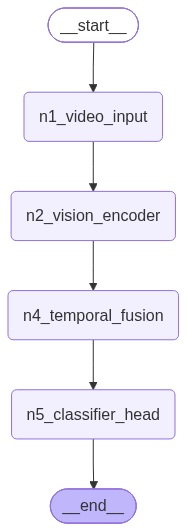

In [29]:
show_graph(vision_graph)

## 6. The Conf. Check gate and the retry loop

The first place the graph makes a *decision*. Until now every edge was
unconditional: `n1_video_input` always went to `n2_vision_encoder`. A
**conditional edge** calls a function that returns the name of the next route.

```python
g.add_conditional_edges("n5_classifier_head", conf_gate, {
    "accept":    END,          # p >= threshold
    "retry":     "retry",      # p <  threshold, budget left
    "exhausted": "degrade",    # p <  threshold, budget spent
})
```

Two things about this that are easy to get wrong:

**A conditional function cannot write to state.** It receives the state and
returns a route name --- that is all. So the retry branch cannot simply point back
at `n1_video_input`, because *something* has to increment the counter that makes
the loop terminate. That is what the `retry` node is for. In Figure 1 the retry
loop is drawn as a single dashed edge; in code that edge needs a body, and the
body is also where the real system would request an alternate camera angle or
slide the sampling window.

**The counter is not optional.** LangGraph does have a `recursion_limit`
(25 by default) that will eventually stop a runaway graph, but it stops it by
raising `GraphRecursionError` --- an accident, not a decision. Our counter makes
exhaustion a *designed* outcome: the graph reports `status="low_confidence"`
instead of pretending it knows what shot it saw.

### Making N5 attempt-aware

`STUB_CONFIDENCE` becomes optionally a sequence, so a retry can genuinely recover
rather than looping on the same number forever. Element `i` is the confidence on
attempt `i`. Re-run the two cells below to redefine the knob and N5.

In [30]:
def conf_gate(state: CricketMindState) -> str:
    """Conf. Check --- the red diamond in Figure 1.

    Returns a ROUTE NAME only. It must not return a state update; LangGraph
    ignores anything a conditional function returns other than the route.
    """
    conf  = state.get("shot_confidence", 0.0)
    tries = state.get("retry_count", 0)

    if conf >= CONF_THRESHOLD:
        trace("GATE", f"p={conf:.2f} >= {CONF_THRESHOLD} -> accept")
        return "accept"

    if tries >= MAX_RETRIES:
        trace("GATE", f"p={conf:.2f} < {CONF_THRESHOLD}, budget spent ({tries}/{MAX_RETRIES}) -> exhausted")
        return "exhausted"

    trace("GATE", f"p={conf:.2f} < {CONF_THRESHOLD} -> retry {tries + 1}/{MAX_RETRIES}")
    return "retry"

In [31]:
def retry_prep(state: CricketMindState) -> dict:
    """The body of the red dashed edge back to N1.

    Real version: request an alternate camera angle, slide the 15-frame sampling
    window, or apply test-time augmentation. Here it only increments the counter
    -- which is the part that makes the loop terminate.
    """
    n = state.get("retry_count", 0) + 1
    trace("RETRY", f"re-sampling clip, attempt {n}")
    return {"retry_count": n}

In [32]:
def low_confidence_exit(state: CricketMindState) -> dict:
    """Graceful degradation once the retry budget is spent.

    Deliberately does NOT clear shot_label: downstream code should be able to
    see what the model guessed *and* that it was not trusted.
    """
    trace("DEGRD", f"giving up after {state.get('retry_count', 0)} retries")
    return {"status": "low_confidence"}

In [33]:
def build_gated_graph():
    """Step 3 graph: vision path + Conf. Check + bounded retry loop."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input", n1_video_input)
    g.add_node("n2_vision_encoder", n2_vision_encoder)
    g.add_node("n4_temporal_fusion", n4_temporal_fusion)
    g.add_node("n5_classifier_head", n5_classifier_head)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    g.add_edge(START, "n1_video_input")
    g.add_edge("n1_video_input", "n2_vision_encoder")
    g.add_edge("n2_vision_encoder", "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    # the red diamond
    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    END,
        "retry":     "retry",
        "exhausted": "degrade",
    })

    g.add_edge("retry", "n1_video_input")          # the red dashed loop
    g.add_edge("degrade", END)

    return g.compile()

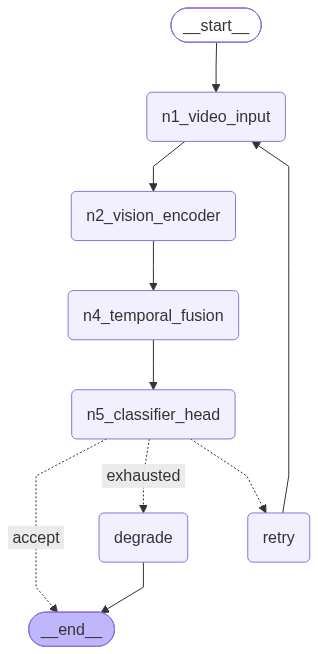

In [34]:
gated_graph = build_gated_graph()
show_graph(gated_graph)

In [35]:
def run_case(title: str, confidence, expect_status: str, expect_retries: int):
    """Run the gated graph with a scripted confidence and check the outcome."""
    global STUB_CONFIDENCE
    saved, STUB_CONFIDENCE = STUB_CONFIDENCE, confidence
    print(f"=== {title}  (STUB_CONFIDENCE={confidence}) " + "=" * max(0, 30 - len(title)))
    try:
        out = gated_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
    finally:
        STUB_CONFIDENCE = saved

    got_status  = out.get("status")
    got_retries = out.get("retry_count", 0)
    print(f"  -> status={got_status!r}  retry_count={got_retries}  p={out['shot_confidence']:.2f}")
    assert got_status  == expect_status,  f"expected status {expect_status!r}, got {got_status!r}"
    assert got_retries == expect_retries, f"expected {expect_retries} retries, got {got_retries}"
    print("  OK\n")
    return out

In [36]:
_ = run_case("A: confident first time", 0.92,
             expect_status="ok", expect_retries=0)

_ = run_case("B: recovers on third attempt", [0.41, 0.55, 0.88],
             expect_status="ok", expect_retries=2)

_ = run_case("C: never recovers, degrades", 0.30,
             expect_status="low_confidence", expect_retries=MAX_RETRIES)

print("PASS: gate accepts, retries with a bound, and degrades instead of looping forever")

=== A: confident first time  (STUB_CONFIDENCE=0.92) =======
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  -> status='ok'  retry_count=0  p=0.92
  OK

=== B: recovers on third attempt  (STUB_CONFIDENCE=[0.41, 0.55, 0.88]) ==
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.41
  [GATE ] p=0.41 < 0.7 -> retry 1/2
  [RETRY] re-sampling clip, attempt 1
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 1: Cover Drive (idx 0) p=0.55
  [GATE ] p=0.55 < 0.7 -> retry 2/2
  [RETRY] re-sampling clip, attempt 2
  [N1   ] sampled 15 frames from clips

## 7.The text branch and the Shot DNA join

Two new nodes, and the first time the graph does more than one thing at once.

**`n3_text_encoder` runs in parallel with the whole vision branch.** Both are
wired straight off `START`:

```python
g.add_edge(START, "n1_video_input")
g.add_edge(START, "n3_text_encoder")
```

That is the entire mechanism --- two edges out of the same node means both run.
LangGraph executes in *supersteps*: everything triggered at the same time runs
together, then their results are merged into state before the next superstep.

N3 does not wait for classification because its output parameterises **retrieval**,
not perception. Which shot the video contains has no bearing on the fact that the
query said "fast bowlers" and "powerplay".

### An edge is a trigger, not a data dependency

This is the trap in this step, and it cost a broken run to find.

Figure 1 draws an arrow from N3 into N6, so the obvious wiring is
`g.add_edge("n3_text_encoder", "n6_shot_dna")`. That is wrong, and it fails like
this:

```
[N1] sampled 15 frames
[N3] query -> (768,), filters={...}
[N2] encoded 15 frames
AssertionError: n6_shot_dna: vision branch delivered no shot_label
```

N6 ran while the vision branch was still at N2. Three experiments pinned down why:

| wiring | accept path | degrade path |
|---|---|---|
| static `n3 -> n6` edge | N6 fires early, crashes | crashes |
| two static parents (`n3` + an `accepted` node) | still fires early | still fires early |
| two static parents, `defer=True` | works | **N6 runs anyway** |
| accept route only | works | N6 correctly skipped |

The lesson: **in LangGraph an edge means "run this next", not "this node needs
that node's output".** A node fires as soon as *any* incoming edge is satisfied
--- there is no all-parents barrier. So a static edge from N3 guarantees N6 runs
right after N3, regardless of the vision branch.

The data dependency is real, but it travels through **state**, not through an
edge. N3 writes `query_embedding` and `query_filters`; N6 reads them from state
whenever it happens to run. The only edge N6 needs is the one that decides
*when* it should run --- the gate's `accept` route.

`defer=True` on N6 then says "run after everything else still pending", which
keeps the join correct if the text branch later grows into several nodes.

In [37]:
def n3_text_encoder(state: CricketMindState) -> dict:
    """Embed the query and pull out the retrieval filters it implies.

    Also extracts which shots the query *names*. The running example compares a
    cover drive with a pull, so retrieval must fetch both -- filtering on the
    shot the video happened to contain would silently drop half the comparison.

    Real version: a sentence embedding plus a structured parse (entity linking
    for the player, phase and bowler-type extraction). The keyword matching here
    is a stand-in that keeps the stub deterministic.
    """
    q = state.get("query")
    assert q, "n3_text_encoder: no query in state"

    ql = q.lower()
    filters = {}

    if "spin" in ql:
        filters["bowler_type"] = "spin"
    elif "pace" in ql or "fast" in ql:
        filters["bowler_type"] = "pace"

    if "powerplay" in ql:
        filters["phase"] = "powerplay"
    elif "death" in ql:
        filters["phase"] = "death"

    for player in ("kohli", "rohit", "babar", "root", "smith"):
        if player in ql:
            filters["player"] = player.capitalize()
            break

    # which shots does the QUERY mention, regardless of what the video showed
    named = [s for s in SHOT_CLASSES if s.lower() in ql]
    if named:
        filters["shots"] = named

    emb = FakeTensor((768,), "query embedding")
    trace("N3", f"query -> {emb.shape}, filters={filters}")
    return {"query_embedding": emb, "query_filters": filters}

In [38]:
# Deterministic stand-in for the continuous visual metrics the real N6 would
# read off the pose estimator. Keyed by shot so the numbers at least move in a
# plausible direction between strokes.
POSTURE_BY_SHOT = {
    "Cover Drive":  {"weight_transfer": 0.88, "bat_face_angle": -4.0, "stride_len": 0.72},
    "Pull":         {"weight_transfer": 0.61, "bat_face_angle": 11.5, "stride_len": 0.34},
    "Sweep":        {"weight_transfer": 0.70, "bat_face_angle":  6.0, "stride_len": 0.55},
}
DEFAULT_POSTURE = {"weight_transfer": 0.65, "bat_face_angle": 0.0, "stride_len": 0.50}

In [39]:
def n6_shot_dna(state: CricketMindState) -> dict:
    """Fuse whatever grounding is available into one structured record.

    This is the interface boundary of the whole system: everything downstream
    consumes shot_dna and never sees a pixel.

    Two ways in. On the **video** path the Conf. Check has accepted a
    classification, so `shot` and `posture` are populated. On the **text-only**
    path there was no clip at all, so both are None and the query's own filters
    carry the whole grounding. N3 must have run either way -- without a query
    there is nothing to ground.

    Posture is deliberately left as None rather than filled with a default when
    no clip was supplied. A default would be an invented measurement entering
    the sanctioned-fact surface, which is precisely the fabrication the Faith
    Check exists to prevent.
    """
    label = state.get("shot_label")
    emb   = state.get("query_embedding")
    assert emb is not None, "n6_shot_dna: n3_text_encoder has not run"

    from_video = label is not None

    dna = {
        "modality":   "video" if from_video else "text",
        "shot":       label,
        "confidence": state.get("shot_confidence") if from_video else None,
        "posture":    POSTURE_BY_SHOT.get(label, DEFAULT_POSTURE) if from_video else None,
        "filters":    state.get("query_filters", {}),
        "attempts":   state.get("retry_count", 0) + 1 if from_video else 0,
    }

    if from_video:
        trace("N6", f"shot_dna: {dna['shot']} p={dna['confidence']:.2f} "
                    f"filters={dna['filters']}")
    else:
        trace("N6", f"shot_dna: text-only, no clip -- filters={dna['filters']}")
    return {"shot_dna": dna}


In [40]:
def build_grounded_graph():
    """Step 4 graph: parallel text branch + gated vision branch, joining at N6.

    Note what is NOT here: an edge from n3_text_encoder to n6_shot_dna. N6 reads
    N3's output out of state. Giving it an edge would make N6 fire the moment N3
    finished, long before the vision branch produced a shot label. See the notes
    above -- an edge is a trigger, not a data dependency.
    """
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input",     n1_video_input)
    g.add_node("n2_vision_encoder",  n2_vision_encoder)
    g.add_node("n4_temporal_fusion", n4_temporal_fusion)
    g.add_node("n5_classifier_head", n5_classifier_head)
    g.add_node("n3_text_encoder",    n3_text_encoder)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    # defer=True: run only once nothing else is pending, so the join stays
    # correct even if the text branch grows into several nodes later.
    g.add_node("n6_shot_dna", n6_shot_dna, defer=True)

    # two edges off START -- this is the whole of "run in parallel"
    g.add_edge(START, "n1_video_input")
    g.add_edge(START, "n3_text_encoder")

    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    # the gate is N6's ONLY trigger
    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })

    g.add_edge("retry", "n1_video_input")
    g.add_edge("n6_shot_dna", END)
    g.add_edge("degrade", END)

    return g.compile()

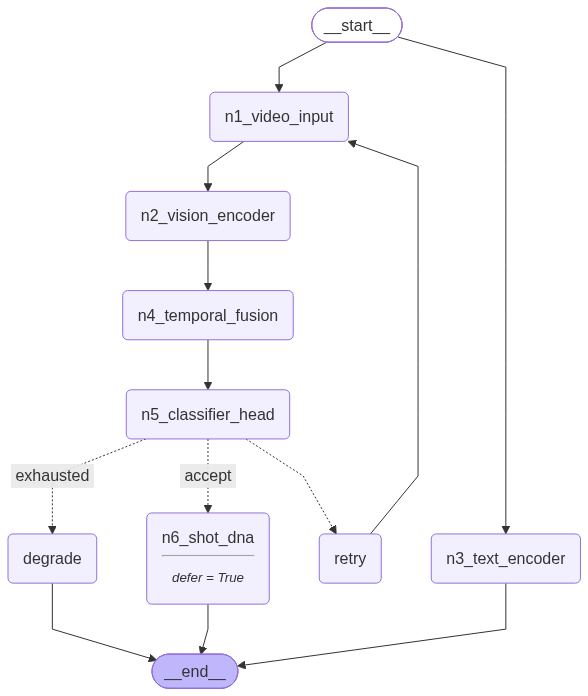

In [41]:
grounded_graph = build_grounded_graph()
show_graph(grounded_graph)

In [42]:
# --- A: accept path. Both branches run; N6 joins them. -----------------
STUB_CONFIDENCE = 0.92
out_a = grounded_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
print("shot_dna:", json.dumps(out_a.get("shot_dna"), indent=2))

assert out_a["shot_dna"]["shot"] == "Cover Drive"

# Check the filters we care about individually rather than comparing the whole
# dict: n3_text_encoder gains new filter keys as the system grows, and an
# exact-equality assertion turns every such addition into a false failure.
f = out_a["shot_dna"]["filters"]
assert f["bowler_type"] == "pace"
assert f["phase"]       == "powerplay"
assert f["player"]      == "Kohli"
print("OK: N6 saw both the vision result and the query filters")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}

shot_dna: {
  "modality": "video",
  "shot": "Cover Drive",
  "confidence": 0.92,
  "posture": {
    "weight_transfer": 0.88,
    "bat_face_angle": -4.0,
    "stride_len": 0.72
  },
  "filters": {
    "bowler_type": "pace",
    "phase": "powerplay",
    "player": "Kohli",
    "shots": [
      "Cover Drive",
      "Pull"
    ]
  },
  "attempts": 1
}
OK: N6 saw both the vision result and the query filters


In [43]:
# --- B: retry path. N3 runs once; N6 still joins correctly. ------------
STUB_CONFIDENCE = [0.41, 0.88]
out_b = grounded_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
print("retry_count:", out_b["retry_count"], "| attempts recorded in dna:", out_b["shot_dna"]["attempts"])
assert out_b["retry_count"] == 1
assert out_b["shot_dna"]["confidence"] == 0.88
print("OK: the loop did not disturb the join")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.41
  [GATE ] p=0.41 < 0.7 -> retry 1/2
  [RETRY] re-sampling clip, attempt 1
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 1: Cover Drive (idx 0) p=0.88
  [GATE ] p=0.88 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.88 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}

retry_count: 1 | attempts recorded in dna: 2
OK: the loop did not disturb the join


In [44]:
# --- C: degrade path. Does N6 run with only one of its two inputs? -----
STUB_CONFIDENCE = 0.30
out_c = grounded_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
print("status  :", out_c.get("status"))
print("shot_dna:", out_c.get("shot_dna"))
assert out_c["status"] == "low_confidence"
assert "query_embedding" in out_c, "N3 should still have run -- it is independent of the gate"
assert out_c.get("shot_dna") is None, "N6 must NOT run when the gate refused to accept"
print("OK: N6 was skipped, not run half-fed and not deadlocked")

STUB_CONFIDENCE = 0.92   # leave the knob in its default state

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.30
  [GATE ] p=0.30 < 0.7 -> retry 1/2
  [RETRY] re-sampling clip, attempt 1
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 1: Cover Drive (idx 0) p=0.30
  [GATE ] p=0.30 < 0.7 -> retry 2/2
  [RETRY] re-sampling clip, attempt 2
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 2: Cover Drive (idx 0) p=0.30
  [GATE ] p=0.30 < 0.7, budget spent (2/2) -> exhausted
  [DEGRD] giving up after 2 retries

status  : low_confidence


## 8.The retrieval fan-out (N7a / N7b)

`n6_shot_dna` now fans out to two retrievers that run at the same time:

```python
g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
g.add_edge("n6_shot_dna", "n7b_context_retrieval")
```

* **N7a** is the narrow, high-precision query --- ball-by-ball deliveries matching
  the player, phase, bowler type and the shots the query named.
* **N7b** is the broad, high-recall envelope --- career and venue context that
  stops the report over-fitting its story to fifty deliveries.

This is the step the Step 1 reducers were written for. Two nodes finishing in the
same superstep both write to state, and how their writes combine is decided
entirely by the `Annotated[...]` on the field.

### The fake corpus is aggregated, not invented

The stub Cricsheet corpus is built from explicit aggregates --- 50 balls of cover
drive for 71 runs, 50 balls of pull for 56 --- expanded into ball-level rows. The
strike rates the Stats Engine will compute in Step 6 therefore *fall out of the
data* (71/50 = 142, 56/50 = 112) rather than being hardcoded to match the thesis
example. That distinction matters: N8 has to do real arithmetic on real rows, or
the Faith Check in Step 9 would be validating against a constant.

In [45]:
def _expand(shot, balls, runs, outs, phase, bowler_type, player):
    """Expand an aggregate into deterministic ball-level rows summing to `runs`.

    A repeating scoring pattern is adjusted until the total matches exactly, so
    the corpus is reproducible and the strike rates are arithmetic rather than
    assertion.
    """
    pattern = [1, 0, 4, 1, 2, 0, 1, 1, 0, 2]
    seq = [pattern[i % len(pattern)] for i in range(balls)]

    diff, i = runs - sum(seq), 0
    while diff and i < balls * 8:
        j = i % balls
        if diff > 0 and seq[j] < 6:
            seq[j] += 1; diff -= 1
        elif diff < 0 and seq[j] > 0:
            seq[j] -= 1; diff += 1
        i += 1
    assert sum(seq) == runs, f"_expand: could not hit {runs} in {balls} balls"

    return [
        {"player": player, "shot": shot, "runs": r, "out": k < outs,
         "phase": phase, "bowler_type": bowler_type}
        for k, r in enumerate(seq)
    ]

In [46]:
# Stand-in for the Cricsheet FAISS index. The last two blocks are deliberate
# noise -- if N7a's filtering is wrong they will leak into the results and the
# strike rates will come out wrong.
FAKE_CRICSHEET = (
    _expand("Cover Drive", balls=50, runs=71, outs=1,
            phase="powerplay", bowler_type="pace",  player="Kohli")   # SR 142
    + _expand("Pull",      balls=50, runs=56, outs=4,
            phase="powerplay", bowler_type="pace",  player="Kohli")   # SR 112
    + _expand("Cover Drive", balls=30, runs=33, outs=1,
            phase="powerplay", bowler_type="spin",  player="Kohli")   # noise
    + _expand("Pull",      balls=20, runs=34, outs=1,
            phase="death",     bowler_type="pace",  player="Kohli")   # noise
)

print(f"fake Cricsheet corpus: {len(FAKE_CRICSHEET)} deliveries")

fake Cricsheet corpus: 150 deliveries


In [47]:
# Stand-in for the broader Kaggle historical index: aggregate context rather
# than individual deliveries.
FAKE_CONTEXT = [
    {"metric": "career_sr_vs_pace",         "player": "Kohli", "value": 138.0},
    {"metric": "venue_sr",                  "player": "Kohli", "value": 151.2,
     "venue": "M. Chinnaswamy Stadium"},
    {"metric": "powerplay_dismissal_rate",  "player": "Kohli", "value": 0.08},
    {"metric": "career_sr_vs_spin",         "player": "Kohli", "value": 121.4},
]

In [48]:
def n7a_stats_retrieval(state: CricketMindState) -> dict:
    """N7a --- narrow, high-precision retrieval from the ball-by-ball index.

    Filters on player, phase and bowler type from the query, and on the union of
    the shot the video showed and any shots the query named. On a text-only
    query the video contributes nothing, so the query must name at least one
    shot itself -- otherwise there is no retrieval key at all.
    """
    dna = state.get("shot_dna")
    assert dna is not None, "n7a_stats_retrieval: n6_shot_dna has not run"
    f = dna["filters"]

    wanted = set(f.get("shots", []))
    if dna.get("shot"):
        wanted.add(dna["shot"])
    assert wanted, ("n7a_stats_retrieval: nothing to retrieve -- a text-only query "
                    "must name at least one shot")

    hits = [
        r for r in FAKE_CRICSHEET
        if r["shot"] in wanted
        and (("player"      not in f) or r["player"]      == f["player"])
        and (("phase"       not in f) or r["phase"]       == f["phase"])
        and (("bowler_type" not in f) or r["bowler_type"] == f["bowler_type"])
    ]

    trace("N7a", f"shots={sorted(wanted)} -> {len(hits)} deliveries "
                 f"(from {len(FAKE_CRICSHEET)})")
    return {"stats_hits": hits}


In [49]:
def n7b_context_retrieval(state: CricketMindState) -> dict:
    """N7b --- broad, high-recall retrieval of historical context.

    Deliberately does NOT filter by shot. Its job is the surrounding envelope:
    career form, venue behaviour, comparable conditions.
    """
    dna = state.get("shot_dna")
    assert dna is not None, "n7b_context_retrieval: n6_shot_dna has not run"
    player = dna["filters"].get("player")

    hits = [r for r in FAKE_CONTEXT if player is None or r["player"] == player]
    trace("N7b", f"player={player} -> {len(hits)} context rows")
    return {"context_hits": hits}

In [50]:
def build_retrieval_graph():
    """Step 5 graph: everything from Step 4, plus the parallel retrieval fan-out."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input",       n1_video_input)
    g.add_node("n2_vision_encoder",    n2_vision_encoder)
    g.add_node("n4_temporal_fusion",   n4_temporal_fusion)
    g.add_node("n5_classifier_head",   n5_classifier_head)
    g.add_node("n3_text_encoder",      n3_text_encoder)
    g.add_node("n6_shot_dna",          n6_shot_dna, defer=True)
    g.add_node("n7a_stats_retrieval",  n7a_stats_retrieval)
    g.add_node("n7b_context_retrieval", n7b_context_retrieval)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    g.add_edge(START, "n1_video_input")
    g.add_edge(START, "n3_text_encoder")

    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })

    # the fan-out: two edges out of one node means both run in parallel
    g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
    g.add_edge("n6_shot_dna", "n7b_context_retrieval")

    g.add_edge("retry", "n1_video_input")
    g.add_edge("n7a_stats_retrieval",  END)
    g.add_edge("n7b_context_retrieval", END)
    g.add_edge("degrade", END)

    return g.compile()

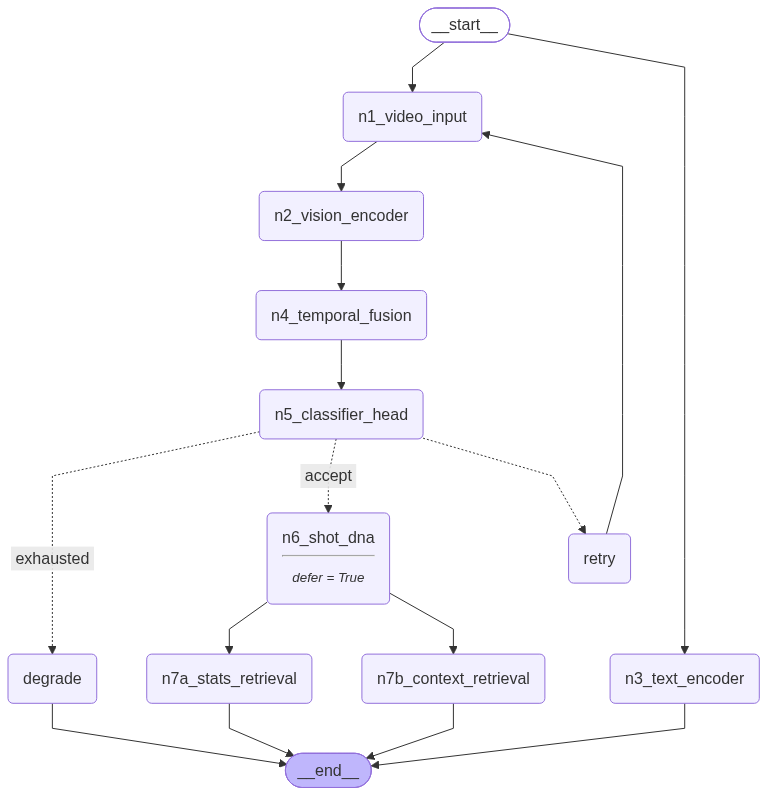

In [51]:
retrieval_graph = build_retrieval_graph()
show_graph(retrieval_graph)

In [52]:
# A: both retrievers land, neither overwrites the other
STUB_CONFIDENCE = 0.92
out = retrieval_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
print("stats_hits  :", len(out["stats_hits"]), "deliveries")
print("context_hits:", len(out["context_hits"]), "rows")
assert len(out["stats_hits"])   == 100, "N7a lost rows"
assert len(out["context_hits"]) == 4,   "N7b lost rows"
print("OK: parallel writes merged, nothing dropped")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows

stats_hits  : 100 deliveries
context_hits: 4 rows
OK: parallel writes merged, nothing dropped


In [53]:
# B: filtering actually filters, and the arithmetic is real
from collections import defaultdict

agg = defaultdict(lambda: {"balls": 0, "runs": 0, "outs": 0})
for r in out["stats_hits"]:
    a = agg[r["shot"]]
    a["balls"] += 1
    a["runs"]  += r["runs"]
    a["outs"]  += int(r["out"])

for shot, a in sorted(agg.items()):
    sr = 100.0 * a["runs"] / a["balls"]
    print(f"  {shot:12s} {a['balls']:3d} balls  {a['runs']:3d} runs  SR {sr:6.1f}  outs {a['outs']}")

assert set(agg) == {"Cover Drive", "Pull"}, "wrong shots retrieved"
assert all(r["bowler_type"] == "pace"      for r in out["stats_hits"]), "spin noise leaked in"
assert all(r["phase"]       == "powerplay" for r in out["stats_hits"]), "death-overs noise leaked in"
assert round(100.0 * agg["Cover Drive"]["runs"] / agg["Cover Drive"]["balls"], 1) == 142.0
assert round(100.0 * agg["Pull"]["runs"]        / agg["Pull"]["balls"],        1) == 112.0
print("OK: SR 142 vs 112 computed from the rows, not hardcoded")

  Cover Drive   50 balls   71 runs  SR  142.0  outs 1
  Pull          50 balls   56 runs  SR  112.0  outs 4
OK: SR 142 vs 112 computed from the rows, not hardcoded


In [54]:
def _make_writer(tag: str):
    """Build a throwaway node that writes a fixed value to `report`.

    A factory rather than two near-identical functions: the point of the
    demonstration is that TWO nodes write THE SAME key in one superstep, and
    the tag is the only thing that differs between them.
    """
    def _writer(state: CricketMindState) -> dict:
        return {"report": f"from {tag}"}
    return _writer

In [55]:
# --- C: why the reducers are needed at all ------------------------------
# `report` is a plain str field with no reducer. Two nodes writing it in the
# same superstep is exactly what an un-annotated parallel write looks like.
_g = StateGraph(CricketMindState)
_g.add_node("a", _make_writer("A"))
_g.add_node("b", _make_writer("B"))
_g.add_edge(START, "a"); _g.add_edge(START, "b")
_g.add_edge("a", END);   _g.add_edge("b", END)

try:
    _g.compile().invoke(new_state("c.mp4", "q"))
    print("no error -- this field must have a reducer after all")
except Exception as e:
    print(f"{type(e).__name__}: {str(e).splitlines()[0]}")
    print()
    print("That is what stats_hits and context_hits would do without")
    print("Annotated[list, operator.add]. The reducer is not decoration.")

InvalidUpdateError: At key 'report': Can receive only one value per step. Use an Annotated key to handle multiple values.

That is what stats_hits and context_hits would do without
Annotated[list, operator.add]. The reducer is not decoration.


## 9.The two shared analytical services (N8 / N9)

These are the nodes that make the Faith Check in Step 9 mean anything.

Neither is an LLM node, even in the finished system. **N8 is arithmetic** over the
rows N7a retrieved; **N9 is sampling** from the distribution those rows describe.
Between them they hold exclusive authority to emit a number, and every one of the
twelve stakeholder agents in Step 8 consumes their output rather than doing sums
inside its own prompt.

That is the central claim of Architecture v2: numeric truth is produced **once**,
by two auditable engines, and then narrated twelve different ways.

### Why they are independent of each other

Both read `stats_hits` and neither reads the other's output. That is deliberate.
N8 and N9 run in the same phase, so if N9 depended on `stats_results` the ordering
between them would be undefined --- the Step 4 lesson again. Instead each derives
what it needs from the same evidence:

| | reads | produces | kind of claim |
|---|---|---|---|
| **N8** | `stats_hits` | strike rates, dismissal rates | observational |
| **N9** | `stats_hits` | counterfactual probabilities | forward-looking |

Both are marked `defer=True`, so they run only once both retrievers have
finished --- otherwise N9, triggered by N7b, could start before N7a had put
`stats_hits` into state at all.

### The 40% is not a coincidence

The thesis example says a batsman facing six back-of-a-length deliveries has
roughly a 40% chance of being dismissed attempting the pull. The corpus gives the
pull 4 dismissals in 50 balls, so `p = 0.08` per ball, and

```
1 - (1 - 0.08)^6  =  0.394
```

N9 arrives at that by Monte Carlo rather than by formula, and the test asserts the
simulation lands within tolerance of the closed form. The number is *derived from
the evidence*, which is precisely what will let the Faith Check reject an agent
that invents a different one.

In [56]:
# N9 simulation settings. Seeded so the notebook is reproducible; the real
# system would report the same interval from any seed given enough trials.
SIM_TRIALS     = 20_000     # Monte Carlo runs
SIM_DELIVERIES = 6          # "what if the bowler sends down six of these?"

print(f"N9: {SIM_TRIALS:,} trials x {SIM_DELIVERIES} deliveries")

N9: 20,000 trials x 6 deliveries


In [57]:
def n8_stats_engine(state: CricketMindState) -> dict:
    """N8 --- Statistical Analysis Engine.

    Deterministic aggregation over the deliveries N7a retrieved. No sampling, no
    generation: every number it emits is a count or a ratio that can be
    recomputed by hand from `stats_hits`. That reproducibility is what makes the
    Faith Check downstream meaningful.
    """
    hits = state.get("stats_hits") or []
    assert hits, "n8_stats_engine: no stats_hits -- did n7a_stats_retrieval run?"

    by_shot = {}
    for r in hits:
        a = by_shot.setdefault(r["shot"], {"balls": 0, "runs": 0, "dismissals": 0})
        a["balls"]      += 1
        a["runs"]       += r["runs"]
        a["dismissals"] += int(r["out"])

    for a in by_shot.values():
        a["strike_rate"]    = round(100.0 * a["runs"] / a["balls"], 1)
        a["dismissal_rate"] = round(a["dismissals"] / a["balls"], 4)

    ranked = sorted(by_shot.items(), key=lambda kv: kv[1]["strike_rate"], reverse=True)
    results = {
        "by_shot":     by_shot,
        "best_shot":   ranked[0][0],
        "worst_shot":  ranked[-1][0],
        "sample_size": len(hits),
    }

    trace("N8", "  ".join(f"{s}: SR {a['strike_rate']}" for s, a in ranked))
    return {"stats_results": results}

In [58]:
def n9_whatif_simulator(state: CricketMindState) -> dict:
    """N9 --- What-If Simulator (Monte Carlo).

    The only source of forward-looking, non-observational claims in the system.
    Answers questions no historical record can answer directly by sampling from
    the distribution the retrieved deliveries describe, and always reports an
    interval alongside the point estimate.
    """
    hits = state.get("stats_hits") or []
    assert hits, "n9_whatif_simulator: no stats_hits -- did n7a_stats_retrieval run?"

    # per-ball dismissal risk by shot, from the same rows N8 reads
    tally = {}
    for r in hits:
        t = tally.setdefault(r["shot"], {"balls": 0, "outs": 0})
        t["balls"] += 1
        t["outs"]  += int(r["out"])

    vulnerable = max(tally, key=lambda s: tally[s]["outs"] / tally[s]["balls"])
    p_ball = tally[vulnerable]["outs"] / tally[vulnerable]["balls"]

    rng = random.Random(SEED)
    dismissed = 0
    for _ in range(SIM_TRIALS):
        for _ in range(SIM_DELIVERIES):
            if rng.random() < p_ball:
                dismissed += 1
                break

    p  = dismissed / SIM_TRIALS
    se = (p * (1 - p) / SIM_TRIALS) ** 0.5

    results = {
        "scenario":       f"{SIM_DELIVERIES} consecutive deliveries targeting the {vulnerable.lower()}",
        "target_shot":    vulnerable,
        "p_ball":         round(p_ball, 4),
        "p_dismissal":    round(p, 4),
        "ci95":           [round(p - 1.96 * se, 4), round(p + 1.96 * se, 4)],
        "analytic_check": round(1 - (1 - p_ball) ** SIM_DELIVERIES, 4),
        "trials":         SIM_TRIALS,
    }

    trace("N9", f"{vulnerable}: p_ball={p_ball:.3f} -> P(out in {SIM_DELIVERIES}) "
                f"= {p:.3f} +/- {1.96 * se:.3f}")
    return {"sim_results": results}

In [59]:
def build_analytics_graph():
    """Step 6 graph: retrieval fan-out feeding the two analytical services."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input",        n1_video_input)
    g.add_node("n2_vision_encoder",     n2_vision_encoder)
    g.add_node("n4_temporal_fusion",    n4_temporal_fusion)
    g.add_node("n5_classifier_head",    n5_classifier_head)
    g.add_node("n3_text_encoder",       n3_text_encoder)
    g.add_node("n6_shot_dna",           n6_shot_dna, defer=True)
    g.add_node("n7a_stats_retrieval",   n7a_stats_retrieval)
    g.add_node("n7b_context_retrieval", n7b_context_retrieval)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    # defer=True: both retrievers must have finished before either engine runs.
    # N9 is triggered by N7b but reads stats_hits, which N7a writes.
    g.add_node("n8_stats_engine",     n8_stats_engine,     defer=True)
    g.add_node("n9_whatif_simulator", n9_whatif_simulator, defer=True)

    g.add_edge(START, "n1_video_input")
    g.add_edge(START, "n3_text_encoder")

    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })

    g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
    g.add_edge("n6_shot_dna", "n7b_context_retrieval")

    g.add_edge("n7a_stats_retrieval",   "n8_stats_engine")
    g.add_edge("n7b_context_retrieval", "n9_whatif_simulator")

    g.add_edge("retry", "n1_video_input")
    g.add_edge("n8_stats_engine",     END)
    g.add_edge("n9_whatif_simulator", END)
    g.add_edge("degrade", END)

    return g.compile()

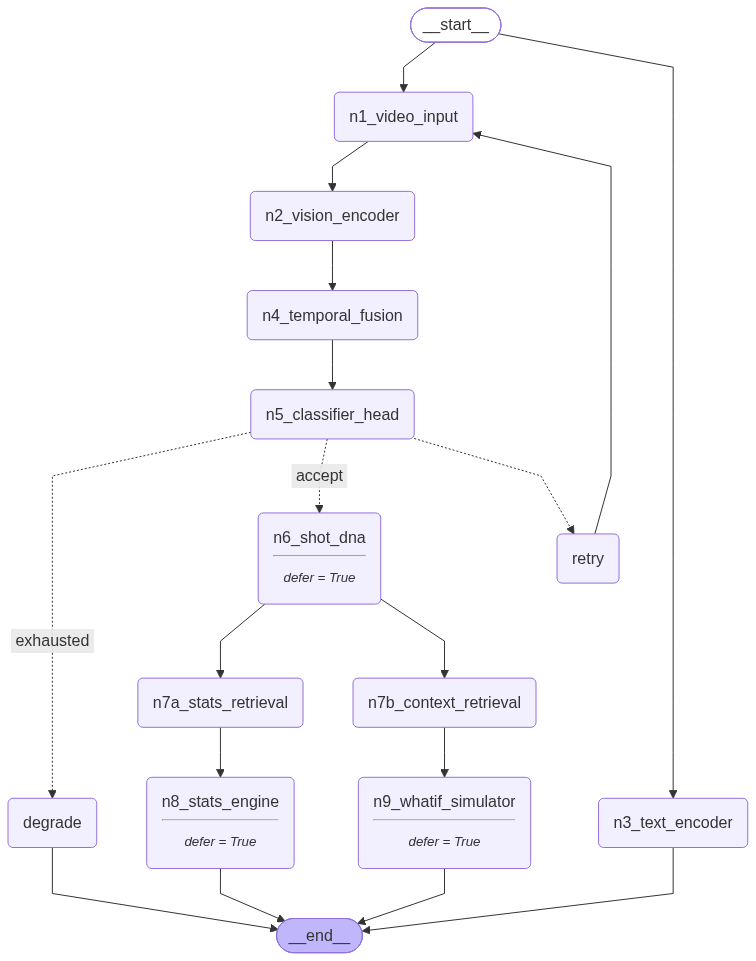

In [60]:
analytics_graph = build_analytics_graph()
show_graph(analytics_graph)

In [61]:
# A: N8 aggregates, and both engines got their evidence
STUB_CONFIDENCE = 0.92
out6 = analytics_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
print(json.dumps(out6["stats_results"], indent=2))

sr = out6["stats_results"]["by_shot"]
assert sr["Cover Drive"]["strike_rate"] == 142.0
assert sr["Pull"]["strike_rate"]        == 112.0
assert out6["stats_results"]["best_shot"]  == "Cover Drive"
assert out6["stats_results"]["worst_shot"] == "Pull"
assert out6["stats_results"]["sample_size"] == 100
print("OK: N8 reproduced SR 142 vs 112 by counting rows")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007

{
  "by_shot": {
    "Cover Drive": {
      "balls": 50,
      "runs": 71,
      "dismissals": 1,
      "strike_rate": 142.0,
      "dismissal_rate": 0.02
    },
    "Pull": {
      "balls": 50,
      "runs": 56,
      "dismissals": 4,
      "strike_rate": 112.0,
 

In [62]:
# B: N9's simulation agrees with the closed form
sim = out6["sim_results"]
print(json.dumps(sim, indent=2))

lo, hi = sim["ci95"]
assert sim["target_shot"] == "Pull", "N9 picked the wrong vulnerable shot"
assert abs(sim["p_dismissal"] - sim["analytic_check"]) < 0.02, "Monte Carlo drifted"
assert lo <= sim["analytic_check"] <= hi, "closed form outside the 95% interval"
print()
print(f"OK: simulated {sim['p_dismissal']:.1%} vs analytic {sim['analytic_check']:.1%}"
      f"  (thesis quotes ~40%)")

{
  "scenario": "6 consecutive deliveries targeting the pull",
  "target_shot": "Pull",
  "p_ball": 0.08,
  "p_dismissal": 0.3941,
  "ci95": [
    0.3873,
    0.4009
  ],
  "analytic_check": 0.3936,
  "trials": 20000
}

OK: simulated 39.4% vs analytic 39.4%  (thesis quotes ~40%)


In [63]:
# --- C: the engines are the only source of numbers ----------------------
# Every figure any agent is allowed to quote in Step 8 must appear here.
sanctioned = {
    "strike rates":     {s: a["strike_rate"]    for s, a in out6["stats_results"]["by_shot"].items()},
    "dismissal rates":  {s: a["dismissal_rate"] for s, a in out6["stats_results"]["by_shot"].items()},
    "sample size":      out6["stats_results"]["sample_size"],
    "P(dismissal)":     out6["sim_results"]["p_dismissal"],
    "95% interval":     out6["sim_results"]["ci95"],
}
for k, v in sanctioned.items():
    print(f"  {k:16s} {v}")

assert out6["stats_results"] and out6["sim_results"], "an engine did not run"
print()
print("These are the values the Faith Check will validate agent claims against.")

  strike rates     {'Cover Drive': 142.0, 'Pull': 112.0}
  dismissal rates  {'Cover Drive': 0.02, 'Pull': 0.08}
  sample size      100
  P(dismissal)     0.3941
  95% interval     [0.3873, 0.4009]

These are the values the Faith Check will validate agent claims against.


## 10.The Supervisor Router (N10)

N10 decides **which of the twelve stakeholder agents to wake**. It does not run
them --- that is Step 8 --- it only writes `active_agents` into state.

Routing is the mechanism that makes a fourteen-agent system legible. Waking all
twelve on every query would be both wasteful and actively harmful: a coach asking
about a match-up would get a sponsorship ROI paragraph and a stadium floodlight
schedule buried in the same report. Your architecture doc puts it as "dispatching
all twelve would bury the answer in irrelevant perspectives", and `MAX_ACTIVE_AGENTS`
is where that becomes enforceable rather than aspirational.

### What the router reads

Three sources, in order of authority:

1. **The query** --- keyword evidence for which stakeholder is actually asking.
2. **The Shot DNA** --- what the video showed, which can wake an agent the words
   did not (a low-confidence classification is a technique question whether or not
   the user said "technique").
3. **The analytics** --- a large gap between the best and worst shot is tactical
   signal, regardless of phrasing.

Keyword matching is a stand-in for a real LLM router. What matters for the graph
is that the *interface* is settled: N10 reads state and writes a list of agent
ids. Replacing the body with an LLM call later changes nothing else.

### Why N10 is deferred

N10 has two incoming edges, one from each engine. As established in Step 4,
LangGraph has no all-parents barrier --- without `defer=True` the router would
fire as soon as whichever engine finished first, and would route on half the
evidence.

In [64]:
# A report that speaks in more than four voices stops being a report. The cap is
# the difference between "dynamic dispatch" and "wake everyone and hope".
MAX_ACTIVE_AGENTS = 4

# Woken when nothing else scores -- the general-purpose pair that can say
# something useful about any delivery.
DEFAULT_AGENTS = ["n11b_tactical_analysis", "n11c_personal_performance"]

In [65]:
# The twelve stakeholder agents of Architecture v2.
#
#   keywords  -- stand-in for a real semantic router (Step 7)
#   template  -- the agent's voice; formatted against the sanctioned facts
#   cites     -- which sanctioned numbers this agent is allowed to quote.
#                Step 9's Faith Check validates exactly these keys, so an agent
#                cannot smuggle in a figure N8 and N9 never produced.
AGENT_REGISTRY = [
    {"id": "n11a_club_operations", "stakeholder": "Franchises / Boards",
     "keywords": ("budget", "auction", "squad", "contract", "fixture", "travel", "roster"),
     "cites": ("best_sr", "sample_size"),
     "template": "Retention case for {player}: {best_shot} returns SR {best_sr} across "
                 "{sample_size} tracked deliveries in this phase, which supports the current "
                 "salary band at the next auction."},

    {"id": "n11b_tactical_analysis", "stakeholder": "Coaches",
     "keywords": ("tactic", "bowl", "field", "matchup", "match-up", "strategy",
                  "weakness", "opposition", "plan", "attack"),
     "cites": ("best_sr", "worst_sr", "p_pct"),
     "template": "Bowl short at {player}. The {worst_shot} returns SR {worst_sr} against "
                 "the {best_shot}'s SR {best_sr}; {deliveries} consecutive back-of-a-length "
                 "deliveries carry a {p_pct}% chance of dismissal."},

    {"id": "n11c_personal_performance", "stakeholder": "Players",
     "keywords": ("technique", "shot", "form", "drive", "pull", "sweep", "cut",
                  "trend", "milestone", "selection"),
     "cites": ("best_sr", "worst_sr", "weight_transfer"),
     "template": "Weight transfer on the {best_shot} measures {weight_transfer}, and it is "
                 "the stronger stroke at SR {best_sr}. The {worst_shot} lags at SR {worst_sr} "
                 "-- shot selection, not technique, is the gap to close."},

    {"id": "n11d_global_scouting", "stakeholder": "Scouts",
     "keywords": ("scout", "emerging", "league", "prospect", "talent pool", "recruit"),
     "cites": ("best_sr", "career_sr"),
     "template": "Benchmark for comparable recruits: SR {best_sr} on the {best_shot} against "
                 "a career SR of {career_sr} versus pace sets the bar for this role."},

    {"id": "n11e_fan_concierge", "stakeholder": "Fans",
     "keywords": ("fan", "fantasy", "ticket", "merchandise", "stadium guide", "highlight"),
     "cites": ("best_sr", "venue_sr"),
     "template": "Fantasy note: {player} strikes at {venue_sr} at this venue and {best_sr} "
                 "on the {best_shot} -- a strong captaincy pick while the field is up."},

    {"id": "n11f_stadium_operations", "stakeholder": "Stadiums",
     "keywords": ("pitch prep", "curator", "crowd", "concession", "floodlight", "drs"),
     "cites": ("sample_size",),
     "template": "Curation note: {sample_size} tracked deliveries in this phase suggest "
                 "the surface is holding pace; no change to the rolling schedule."},

    {"id": "n11g_sponsorship_intelligence", "stakeholder": "Sponsors",
     "keywords": ("sponsor", "brand", "logo", "roi", "impression", "visibility"),
     "cites": ("best_sr",),
     "template": "Visibility: boundary strokes drive replay volume, and the {best_shot} at "
                 "SR {best_sr} is this batsman's most replayed shot -- prime logo exposure."},

    {"id": "n11h_content_production", "stakeholder": "Broadcasters",
     "keywords": ("commentary", "broadcast", "overlay", "wagon wheel", "clip",
                  "highlight", "graphic"),
     "cites": ("best_sr", "worst_sr"),
     "template": "Ticker line: \"{player} -- {best_shot} SR {best_sr}, {worst_shot} SR "
                 "{worst_sr} in the powerplay.\" Wagon wheel overlay ready."},

    {"id": "n11i_compliance", "stakeholder": "Governing Bodies",
     "keywords": ("eligibility", "compliance", "icc", "audit", "bio-bubble", "sanction"),
     "cites": ("sample_size",),
     "template": "No eligibility or conduct flags attached to the {sample_size} deliveries "
                 "reviewed. Match officials' records are consistent."},

    {"id": "n11j_talent_development", "stakeholder": "Academies",
     "keywords": ("academy", "u-16", "u-19", "drill", "coaching plan", "development"),
     "cites": ("worst_sr", "weight_transfer"),
     "template": "Drill focus for age-group squads: replicate the {weight_transfer} weight "
                 "transfer of the {best_shot}; the {worst_shot} at SR {worst_sr} is the "
                 "stroke to rebuild first."},

    {"id": "n11k_injury_management", "stakeholder": "Medical Teams",
     "keywords": ("injury", "workload", "fatigue", "fitness", "recovery",
                  "hamstring", "return-to-play"),
     "cites": ("sample_size",),
     "template": "Workload: {sample_size} deliveries faced in this phase sits inside the "
                 "weekly threshold. No soft-tissue risk flag raised."},

    {"id": "n11l_player_representation", "stakeholder": "Player Agents / Managers",
     "keywords": ("valuation", "market", "agent", "transfer", "salary", "worth"),
     "cites": ("best_sr", "career_sr"),
     "template": "Valuation input: SR {best_sr} on the {best_shot} against a career SR of "
                 "{career_sr} versus pace supports a top-bracket ask this cycle."},
]

AGENTS_BY_ID = {a["id"]: a for a in AGENT_REGISTRY}
print(f"{len(AGENT_REGISTRY)} stakeholder agents registered")

12 stakeholder agents registered


In [66]:
def _score_agents(state: CricketMindState) -> dict:
    """Score every agent against the query, the Shot DNA and the analytics.

    Returns {agent_id: (score, [reasons])}. Split out from the router so the
    selection logic can be inspected on its own -- this is the part that will be
    replaced by an LLM call, and it is easier to compare against a rubric when it
    is not tangled up with graph plumbing.
    """
    q      = (state.get("query") or "").lower()
    dna    = state.get("shot_dna") or {}
    stats  = (state.get("stats_results") or {}).get("by_shot", {})
    scores = {}

    # 1. keyword evidence from the query
    for a in AGENT_REGISTRY:
        hits = [k for k in a["keywords"] if k in q]
        if hits:
            scores[a["id"]] = [len(hits), [f"query mentions {', '.join(hits)}"]]

    # 2. structural signal: a shaky classification is a technique question.
    #    A text-only query has no visual confidence at all, so the signal does
    #    not apply. Note dna.get("confidence", 1.0) would return None here, not
    #    the default -- the key exists, its value is None.
    conf = dna.get("confidence")
    if conf is not None and conf < 0.80:
        e = scores.setdefault("n11c_personal_performance", [0, []])
        e[0] += 1
        e[1].append(f"low visual confidence ({conf:.2f})")

    # 3. structural signal: a wide spread between shots is tactical
    if len(stats) >= 2:
        rates = [a["strike_rate"] for a in stats.values()]
        if max(rates) - min(rates) >= 20:
            e = scores.setdefault("n11b_tactical_analysis", [0, []])
            e[0] += 1
            e[1].append(f"SR spread {max(rates) - min(rates):.0f} between shots")

    return {k: (v[0], v[1]) for k, v in scores.items()}

### Agents whose evidence does not exist

The sanctioned-fact surface is not fixed. A text-only query carries no clip, so
no posture was measured and `weight_transfer` is absent from
`sanctioned_facts`. Two agents --- Players and Academies --- are required to
cite it.

They must therefore **not be woken**. Filling the gap with a default posture
would put an invented measurement into the sanctioned facts, where the Faith
Check would then verify it as truth. Declining to wake the agent is the honest
option: the report is shorter, and everything left in it is still grounded.

This is the same trade Result 2 measures --- containment is paid for in
completeness.

In [67]:
def agents_missing_facts(state: CricketMindState) -> set:
    """Agent ids whose required citations this query cannot supply.

    Kept separate from the scoring so the reason an agent stayed asleep is
    "its evidence does not exist", not "it scored low".
    """
    dna = state.get("shot_dna") or {}
    if dna.get("posture"):
        return set()
    return {a["id"] for a in AGENT_REGISTRY if "weight_transfer" in a["cites"]}


In [68]:
def n10_supervisor_router(state: CricketMindState) -> dict:
    """N10 --- Supervisor Router. Chooses which agents run; does not run them.

    Writes `active_agents` only. Step 8 turns that list into an actual fan-out.
    Agents whose citations cannot be satisfied by this query are removed before
    ranking, so they never reach the fan-out at all.
    """
    scored  = _score_agents(state)
    blocked = agents_missing_facts(state)
    if blocked:
        skipped = [a for a in scored if a in blocked]
        scored  = {k: v for k, v in scored.items() if k not in blocked}
        if skipped:
            trace("N10", f"no evidence for {len(skipped)}: "
                         + ", ".join(AGENTS_BY_ID[a]["stakeholder"] for a in skipped))

    if not scored:
        chosen = [a for a in DEFAULT_AGENTS if a not in blocked]
        trace("N10", f"no signal -> default {[AGENTS_BY_ID[c]['stakeholder'] for c in chosen]}")
        return {"active_agents": chosen}

    # highest score first; ties broken by registry order so runs are reproducible
    order = {a["id"]: i for i, a in enumerate(AGENT_REGISTRY)}
    ranked = sorted(scored.items(), key=lambda kv: (-kv[1][0], order[kv[0]]))
    chosen = [aid for aid, _ in ranked[:MAX_ACTIVE_AGENTS]]

    trace("N10", f"woke {len(chosen)}/{len(AGENT_REGISTRY)}: "
                 + ", ".join(AGENTS_BY_ID[c]["stakeholder"] for c in chosen))
    for aid in chosen:
        trace("  ->", f"{aid}: {'; '.join(scored[aid][1])}")

    return {"active_agents": chosen}


In [69]:
def build_router_graph():
    """Step 7 graph: everything so far, plus the supervisor router."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input",        n1_video_input)
    g.add_node("n2_vision_encoder",     n2_vision_encoder)
    g.add_node("n4_temporal_fusion",    n4_temporal_fusion)
    g.add_node("n5_classifier_head",    n5_classifier_head)
    g.add_node("n3_text_encoder",       n3_text_encoder)
    g.add_node("n6_shot_dna",           n6_shot_dna,         defer=True)
    g.add_node("n7a_stats_retrieval",   n7a_stats_retrieval)
    g.add_node("n7b_context_retrieval", n7b_context_retrieval)
    g.add_node("n8_stats_engine",       n8_stats_engine,     defer=True)
    g.add_node("n9_whatif_simulator",   n9_whatif_simulator, defer=True)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    # defer=True: two incoming edges, and LangGraph has no all-parents barrier
    g.add_node("n10_supervisor_router", n10_supervisor_router, defer=True)

    g.add_edge(START, "n1_video_input")
    g.add_edge(START, "n3_text_encoder")

    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })

    g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
    g.add_edge("n6_shot_dna", "n7b_context_retrieval")
    g.add_edge("n7a_stats_retrieval",   "n8_stats_engine")
    g.add_edge("n7b_context_retrieval", "n9_whatif_simulator")

    g.add_edge("n8_stats_engine",     "n10_supervisor_router")
    g.add_edge("n9_whatif_simulator", "n10_supervisor_router")

    g.add_edge("retry", "n1_video_input")
    g.add_edge("n10_supervisor_router", END)
    g.add_edge("degrade", END)

    return g.compile()

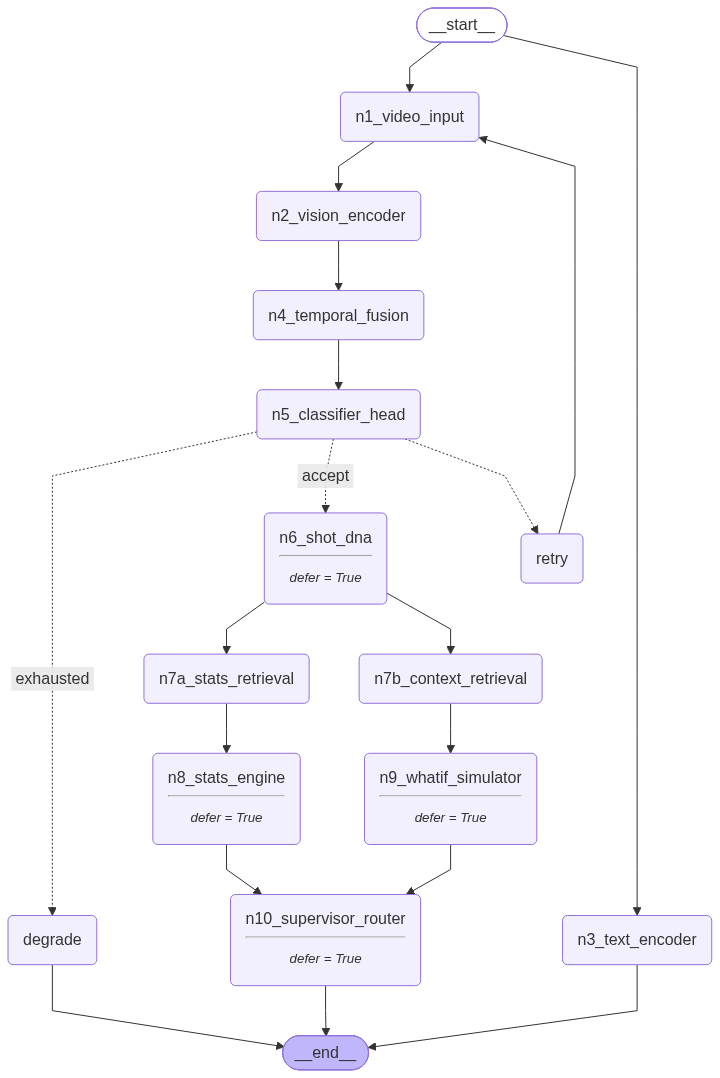

In [70]:
router_graph = build_router_graph()
show_graph(router_graph)

In [71]:
#A: the running example wakes the coach and the player
STUB_CONFIDENCE = 0.92
out7 = router_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
for aid in out7["active_agents"]:
    print(f"  {aid:32s} {AGENTS_BY_ID[aid]['stakeholder']}")

assert "n11b_tactical_analysis"    in out7["active_agents"]
assert "n11c_personal_performance" in out7["active_agents"]
assert len(out7["active_agents"]) <= MAX_ACTIVE_AGENTS
print()
print("OK: a match-up question woke the tactical and player agents")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007
  [N10  ] woke 2/12: Players, Coaches
  [  -> ] n11c_personal_performance: query mentions shot, drive, pull
  [  -> ] n11b_tactical_analysis: query mentions bowl; SR spread 30 between shots

  n11c_personal_performance        Players
  n11b_tactical_analysis        

In [72]:
# B: different stakeholders, different agents
TRACE = False
PROBES = [
    ("workload / injury",  "How much workload has Kohli carried this week, any injury risk?"),
    ("market valuation",   "What is Kohli's IPL auction valuation and market worth?"),
    ("broadcast",          "Generate commentary and a wagon wheel overlay clip"),
    ("compliance",         "Check ICC eligibility and audit the franchise"),
    ("vague",              "Tell me about this delivery"),
]

for label, q in PROBES:
    res = router_graph.invoke(new_state("clips/kohli_01.mp4", q))
    names = [AGENTS_BY_ID[a]["stakeholder"] for a in res["active_agents"]]
    print(f"  {label:18s} -> {names}")

TRACE = True

  workload / injury  -> ['Medical Teams']
  market valuation   -> ['Player Agents / Managers', 'Franchises / Boards']
  broadcast          -> ['Broadcasters']
  compliance         -> ['Governing Bodies']
  vague              -> ['Coaches', 'Players']


In [73]:
#C: the router never wakes everyone
TRACE = False
worst_case = ("budget auction squad tactic bowling technique shot scout league "
              "fan fantasy pitch prep crowd sponsor logo roi commentary overlay "
              "eligibility icc academy drill injury workload valuation market")

res = router_graph.invoke(new_state("clips/kohli_01.mp4", worst_case))
TRACE = True

print(f"  query matching every agent -> woke {len(res['active_agents'])}")
for aid in res["active_agents"]:
    print(f"    {AGENTS_BY_ID[aid]['stakeholder']}")

assert len(res["active_agents"]) == MAX_ACTIVE_AGENTS
assert len(res["active_agents"]) < len(AGENT_REGISTRY)
print()
print("OK: dispatch stays bounded even when every keyword fires")

  query matching every agent -> woke 4
    Franchises / Boards
    Sponsors
    Coaches
    Players

OK: dispatch stays bounded even when every keyword fires


## 11.The twelve stakeholder agents (N11a-N11l)

Twelve agents, **one factory**. Each is the same shape --- read the sanctioned
facts, say something in its own vocabulary --- and differs only in configuration:
its id, its stakeholder, its template and, critically, **which numbers it is
allowed to cite**.

Twelve copy-pasted functions would be twelve places to fix every future change,
and twelve places for a bug to hide in eleven of them.

### Dynamic fan-out

Step 7's router wrote `active_agents`. Turning that list into actual execution is
one conditional edge whose function returns **a list of node names** rather than a
single one:

```python
def dispatch_agents(state):
    return state.get("active_agents") or [END]

g.add_conditional_edges("n10_supervisor_router", dispatch_agents,
                        [a["id"] for a in AGENT_REGISTRY] + [END])
```

All twelve nodes are registered; only the named subset runs. That is the whole
mechanism --- a conditional function returning a list is LangGraph's fan-out.

### Citations are the point

Every finding carries a `cites` dict: the exact fact keys and values the agent
quoted. That is not decoration --- it is what makes Step 9 possible. The Faith
Check does not have to parse prose looking for numbers; it compares each cited
value against what N8 and N9 actually produced.

An agent that invents a figure has to invent it *in its citations*, where it is
trivially caught. This is the payoff for the Architecture v2 split: because the
two engines are the only sanctioned sources of numbers, there is a single
ground-truth surface to validate against.

In [74]:
def sanctioned_facts(state: CricketMindState) -> dict:
    """Every number an agent is permitted to use, in one flat dict.

    Sourced only from N8 (`stats_results`), N9 (`sim_results`), N6's posture
    metrics and N7b's context rows. If a value is not in here, no agent may
    quote it -- and Step 9 enforces that.

    The surface is **dynamic**. A text-only query carries no clip, so no posture
    was measured and `weight_transfer` is simply absent rather than defaulted.
    The router reads the same rule and declines to wake any agent whose
    citations cannot be satisfied.
    """
    stats = state["stats_results"]
    sim   = state["sim_results"]
    dna   = state["shot_dna"]

    best, worst = stats["best_shot"], stats["worst_shot"]
    ctx = {r["metric"]: r["value"] for r in (state.get("context_hits") or [])}

    facts = {
        "player":          dna["filters"].get("player", "the batsman"),
        "best_shot":       best,
        "worst_shot":      worst,
        "best_sr":         stats["by_shot"][best]["strike_rate"],
        "worst_sr":        stats["by_shot"][worst]["strike_rate"],
        "sample_size":     stats["sample_size"],
        "p_pct":           round(sim["p_dismissal"] * 100, 1),
        "deliveries":      SIM_DELIVERIES,
        "target_shot":     sim["target_shot"],
        "career_sr":       ctx.get("career_sr_vs_pace"),
        "venue_sr":        ctx.get("venue_sr"),
    }

    # video-only facts: present only when a clip was actually analysed
    if dna.get("shot"):
        facts["shot"] = dna["shot"]
    if dna.get("posture"):
        facts["weight_transfer"] = dna["posture"]["weight_transfer"]

    return facts


In [75]:
# Injection knobs for Step 9. An agent named here fabricates one of the figures
# it cites, which is what gives the Faith Check something real to catch.
HALLUCINATE_ONCE   = set()   # lies on the first attempt, corrects itself after
HALLUCINATE_ALWAYS = set()   # never corrects -- exercises the regenerate budget


def make_agent(config: dict):
    """Build one stakeholder agent node from its registry entry.

    A factory rather than twelve functions: the agents differ only in voice and
    in which facts they may quote, so that difference belongs in data. The node
    keeps the standard `(state) -> dict` signature, so an agent can later become
    a real LLM call without the graph changing.
    """
    def _agent(state: CricketMindState) -> dict:
        cid   = config["id"]
        facts = sanctioned_facts(state)

        lying = (cid in HALLUCINATE_ALWAYS) or (
            cid in HALLUCINATE_ONCE and state.get("regen_count", 0) == 0)
        if lying:
            # corrupt the fact itself, so the prose and the citation agree --
            # exactly the failure mode the Faith Check exists to catch
            facts = {**facts, config["cites"][0]: 999.0}

        text  = config["template"].format(**facts)
        cites = {k: facts[k] for k in config["cites"]}

        trace("N11", f"{config['stakeholder']}: cites {list(cites)}"
                     + ("   <-- FABRICATED" if lying else ""))
        return {"agent_findings": [{
            "agent":       cid,
            "stakeholder": config["stakeholder"],
            "text":        text,
            "cites":       cites,
        }]}

    _agent.__name__ = config["id"]
    return _agent

In [76]:
# One node per registry entry. All twelve are registered on the graph; the
# router decides which of them actually run.
AGENT_NODES = {a["id"]: make_agent(a) for a in AGENT_REGISTRY}
print(f"built {len(AGENT_NODES)} agent nodes from one factory")

built 12 agent nodes from one factory


In [77]:
def dispatch_agents(state: CricketMindState) -> list:
    """Conditional edge that returns a LIST -- LangGraph's fan-out.

    Every name returned is executed in the same superstep. Returning [END]
    rather than [] matters: an empty list leaves the graph with nothing to do
    and no way to finish.
    """
    chosen = state.get("active_agents") or []
    return chosen if chosen else [END]

In [78]:
def build_agent_graph():
    """Step 8 graph: the router now fans out to the chosen stakeholder agents."""
    g = StateGraph(CricketMindState)

    g.add_node("n1_video_input",        n1_video_input)
    g.add_node("n2_vision_encoder",     n2_vision_encoder)
    g.add_node("n4_temporal_fusion",    n4_temporal_fusion)
    g.add_node("n5_classifier_head",    n5_classifier_head)
    g.add_node("n3_text_encoder",       n3_text_encoder)
    g.add_node("n6_shot_dna",           n6_shot_dna,           defer=True)
    g.add_node("n7a_stats_retrieval",   n7a_stats_retrieval)
    g.add_node("n7b_context_retrieval", n7b_context_retrieval)
    g.add_node("n8_stats_engine",       n8_stats_engine,       defer=True)
    g.add_node("n9_whatif_simulator",   n9_whatif_simulator,   defer=True)
    g.add_node("n10_supervisor_router", n10_supervisor_router, defer=True)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    for aid, fn in AGENT_NODES.items():
        g.add_node(aid, fn)

    g.add_edge(START, "n1_video_input")
    g.add_edge(START, "n3_text_encoder")
    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })

    g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
    g.add_edge("n6_shot_dna", "n7b_context_retrieval")
    g.add_edge("n7a_stats_retrieval",   "n8_stats_engine")
    g.add_edge("n7b_context_retrieval", "n9_whatif_simulator")
    g.add_edge("n8_stats_engine",     "n10_supervisor_router")
    g.add_edge("n9_whatif_simulator", "n10_supervisor_router")

    # the fan-out: one conditional edge, many possible destinations
    g.add_conditional_edges("n10_supervisor_router", dispatch_agents,
                            list(AGENT_NODES) + [END])

    for aid in AGENT_NODES:
        g.add_edge(aid, END)

    g.add_edge("retry", "n1_video_input")
    g.add_edge("degrade", END)

    return g.compile()

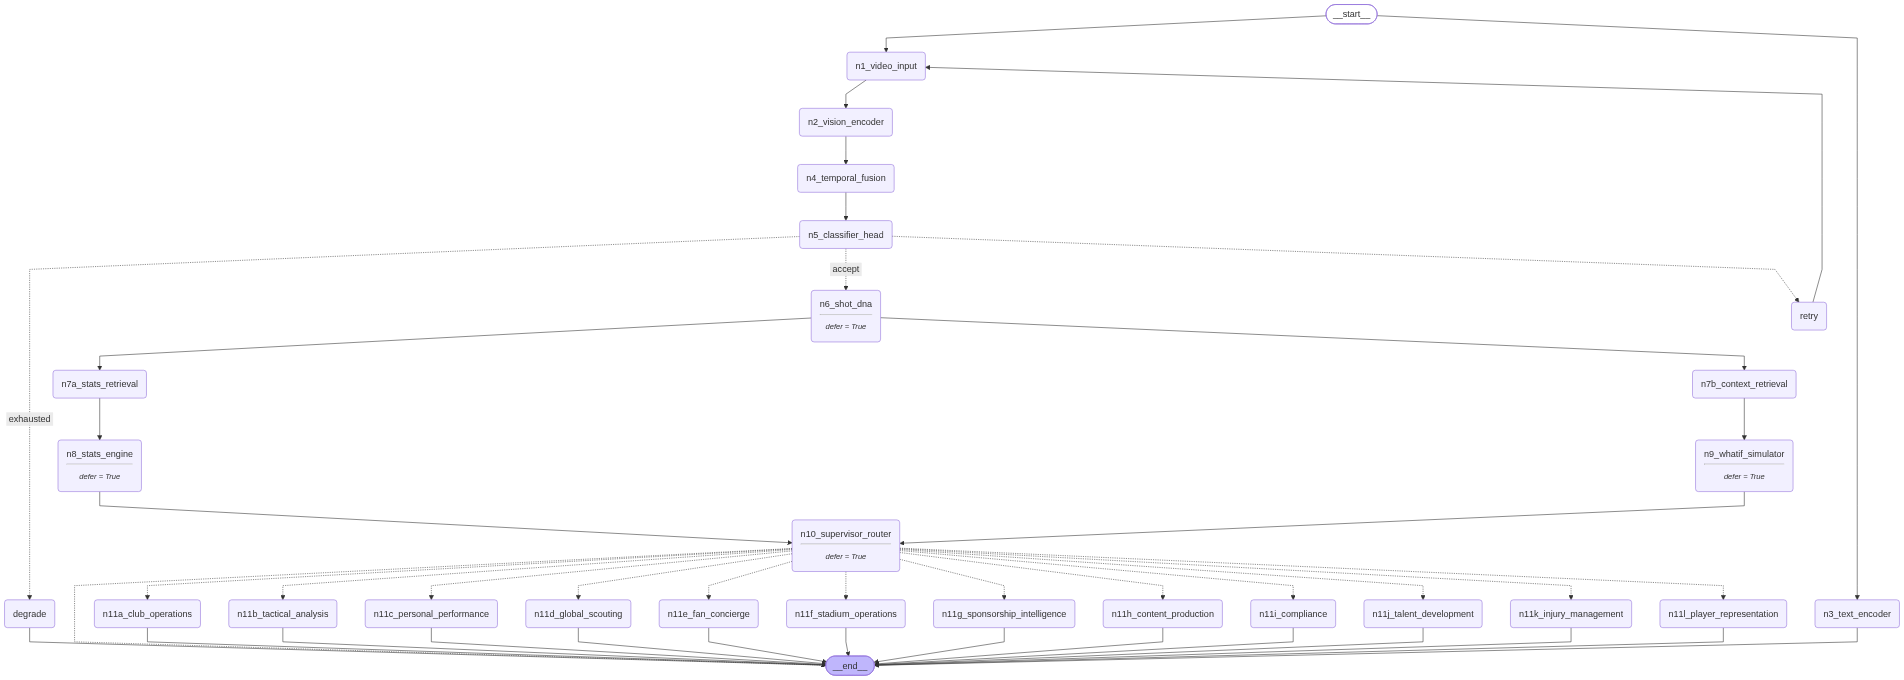

In [79]:
agent_graph = build_agent_graph()
show_graph(agent_graph)

In [80]:
# A: only the routed agents produce findings
STUB_CONFIDENCE = 0.92
out8 = agent_graph.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
for f in out8["agent_findings"]:
    print(f"  [{f['stakeholder']}]")
    print(f"    {f['text']}")
    print(f"    cites: {f['cites']}")
    print()

ran = {f["agent"] for f in out8["agent_findings"]}
assert ran == set(out8["active_agents"]), "an agent ran that was not dispatched"
assert len(ran) < len(AGENT_REGISTRY), "everything ran -- the fan-out ignored the router"
print(f"OK: {len(ran)} of {len(AGENT_REGISTRY)} agents ran, exactly the routed set")

  [N1   ] sampled 15 frames from clips/kohli_01.mp4  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}

  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007
  [N10  ] woke 2/12: Players, Coaches
  [  -> ] n11c_personal_performance: query mentions shot, drive, pull
  [  -> ] n11b_tactical_analysis: query mentions bowl; SR spread 30 between shots
  [N11  ] Coaches: cites ['best_sr', 'worst_sr', 'p_pct']
  [N11  ] Players:

In [81]:
# B: every cited number really came from N8 or N9
facts = sanctioned_facts(out8)
bad = []
for f in out8["agent_findings"]:
    for key, value in f["cites"].items():
        if key not in facts or facts[key] != value:
            bad.append((f["agent"], key, value, facts.get(key)))

for f in out8["agent_findings"]:
    print(f"  {f['agent']:32s} {f['cites']}")

assert not bad, f"unsanctioned citations: {bad}"
print()
print("OK: every quoted figure matches the engines' output")

  n11b_tactical_analysis           {'best_sr': 142.0, 'worst_sr': 112.0, 'p_pct': 39.4}
  n11c_personal_performance        {'best_sr': 142.0, 'worst_sr': 112.0, 'weight_transfer': 0.88}

OK: every quoted figure matches the engines' output


In [82]:
# C: four agents in parallel, no lost or duplicated findings
TRACE = False
wide = ("bowling tactics, injury workload, auction valuation and technique "
        "for Kohli's pull shot against pace in the powerplay")
out8c = agent_graph.invoke(new_state("clips/kohli_01.mp4", wide))
TRACE = True

print(f"  routed : {len(out8c['active_agents'])} agents")
for f in out8c["agent_findings"]:
    print(f"    {f['stakeholder']}")

ids = [f["agent"] for f in out8c["agent_findings"]]
assert len(ids) == len(set(ids)), "upsert_findings duplicated an agent"
assert set(ids) == set(out8c["active_agents"])
assert len(ids) == MAX_ACTIVE_AGENTS
print()
print("OK: parallel agent writes merged cleanly through upsert_findings")

  routed : 4 agents
    Franchises / Boards
    Coaches
    Players
    Medical Teams

OK: parallel agent writes merged cleanly through upsert_findings


## 12.The Faith Check and the regenerate loop

The hallucination gate. Every number an agent quoted is compared against what N8
and N9 actually produced; anything unsupported sends that agent back.

### Why this is cheap in Architecture v2

The gate never parses prose. Step 8 made every agent record its citations
explicitly, and `sanctioned_facts()` is built only from the two engines, N6's
posture metrics and N7b's context. So verification is a dict comparison:

```python
for key, value in finding["cites"].items():
    if truth.get(key) != value:
        # unsupported claim
```

In the six-worker Version 1, where each worker did its own arithmetic, there was
no authoritative value to compare *against* --- the gate would have had to
adjudicate twelve independent chains of reasoning. Splitting the analytical
services out is what turns hallucination detection from a judgement call into an
equality test.

### The loop needs somewhere to put its counter

Same shape as the retry loop in Step 3. A conditional function returns a route
and cannot write state, so `regen_prep` owns `regen_count`, and a second
conditional fans back out to exactly the agents that failed --- not all of them.

### One correction to Step 1

`faith_failures` was declared with `Annotated[list, operator.add]`. That was
wrong. Only one node ever writes it, and on the second pass through the loop the
reducer would append the new failures to the stale ones, so a corrected agent
would look like it was still failing. Reducers are for fields written by
**parallel** nodes; a field written by a single node wants plain last-write-wins.
It is now a plain `list`.

### When a fan-in does *not* need `defer`

N6, N8, N9 and N10 are all `defer=True` because each waits on a branch of a
different depth. `faith_check` is not, and the distinction is worth stating
precisely:

* **Parents at different depths** (N6 waiting on both a one-node text branch and a
  four-node vision branch) need `defer` --- LangGraph has no all-parents barrier,
  so the shallow branch would trigger the node early.
* **Siblings from one fan-out** (the twelve agents) do not. They are dispatched by a
  single conditional edge into the same superstep, and a superstep completes as a
  unit, so `faith_check` is triggered once with all findings present.

Adding `defer=True` here was not merely redundant: it made `get_graph()` draw a
phantom `n13_final_output -> faith_check` edge and drop `n13_final_output -> END`
entirely. The runtime was correct either way --- `builder.edges` had the right
wiring --- but the rendered diagram, which is what goes in the thesis, was not.

In [83]:
def n_faith_check(state: CricketMindState) -> dict:
    """Faith Check -- the purple diamond.

    Compares every cited figure against the sanctioned facts. Writes the failure
    list (replacing it, not appending: see the note above).
    """
    truth    = sanctioned_facts(state)
    failures = []

    for f in state.get("agent_findings") or []:
        if f.get("rejected"):
            continue
        for key, claimed in f["cites"].items():
            actual = truth.get(key)
            if actual != claimed:
                failures.append({"agent": f["agent"], "key": key,
                                 "claimed": claimed, "actual": actual})

    if failures:
        for x in failures:
            trace("FAITH", f"REJECT {x['agent']}: {x['key']}={x['claimed']} "
                           f"but engines say {x['actual']}")
    else:
        trace("FAITH", f"all {len(state.get('agent_findings') or [])} findings verified")

    return {"faith_failures": failures}

In [84]:
def faith_gate(state: CricketMindState) -> str:
    """Route on the Faith Check result. Returns a route name only."""
    fails = state.get("faith_failures") or []
    if not fails:
        return "faithful"
    if state.get("regen_count", 0) >= MAX_REGENS:
        trace("FAITH", f"regenerate budget spent ({MAX_REGENS}) -> dropping claims")
        return "exhausted"
    return "regenerate"

In [85]:
def regen_prep(state: CricketMindState) -> dict:
    """Body of the regenerate edge: owns the counter that bounds the loop."""
    n = state.get("regen_count", 0) + 1
    who = sorted({f["agent"] for f in state["faith_failures"]})
    trace("REGEN", f"pass {n}/{MAX_REGENS}, re-running {len(who)}: {', '.join(who)}")
    return {"regen_count": n}

In [86]:
def dispatch_regen(state: CricketMindState) -> list:
    """Fan back out to exactly the agents that failed -- not all of them."""
    return sorted({f["agent"] for f in state.get("faith_failures") or []})

In [87]:
def drop_unfaithful(state: CricketMindState) -> dict:
    """Budget spent: withhold the unverifiable findings rather than publish them.

    Marks rather than deletes, because `agent_findings` merges through
    upsert_findings -- returning a shorter list would not remove anything. N12
    skips anything flagged, and the report says plainly what was withheld.
    """
    bad    = {f["agent"] for f in state["faith_failures"]}
    marked = [{**f, "rejected": True}
              for f in state["agent_findings"] if f["agent"] in bad]
    trace("DROP", f"withholding {len(marked)} unverifiable finding(s)")
    return {"agent_findings": marked, "status": "unverified_claims_dropped"}

## 13.Synthesis, output, and the finished graph

`n12_supervisor_synthesis` assembles the verified findings into one report,
ordered by the router's own ranking so the most relevant stakeholder speaks
first. `n13_final_output` is the terminal node.

Anything the Faith Check withheld is named in the report rather than silently
dropped --- a reader should be able to see that an agent was overruled.

In [88]:
def n12_supervisor_synthesis(state: CricketMindState) -> dict:
    """N12 -- Supervisor LLM. Composes the verified findings into one report.

    Real version: an LLM call that resolves overlap between agents and writes
    connective prose. The ordering and the withheld-claims section are policy,
    not generation, so they stay here either way.
    """
    all_findings = state.get("agent_findings") or []
    kept    = [f for f in all_findings if not f.get("rejected")]
    dropped = [f for f in all_findings if f.get("rejected")]

    rank = {a: i for i, a in enumerate(state.get("active_agents") or [])}
    kept.sort(key=lambda f: rank.get(f["agent"], 99))

    dna, stats, sim = state["shot_dna"], state["stats_results"], state["sim_results"]
    sr_line = ", ".join(f"{s} SR {a['strike_rate']}" for s, a in stats["by_shot"].items())

    lines = [
        f"CRICKETMIND REPORT -- {dna['filters'].get('player', 'batsman')}",
        "=" * 72,
        f"Query      : {state['query']}",
        (f"Vision     : {dna['shot']} at {dna['confidence']:.0%} confidence "
         f"({dna['attempts']} attempt(s))") if dna.get("shot")
        else "Vision     : no clip supplied -- text-only query",
        f"Evidence   : {stats['sample_size']} deliveries -- {sr_line}",
        f"Simulation : {sim['scenario']} -> {sim['p_dismissal']:.1%} "
        f"(95% CI {sim['ci95'][0]:.1%}-{sim['ci95'][1]:.1%}, {sim['trials']:,} trials)",
        "",
        f"FINDINGS ({len(kept)} agent(s))",
        "-" * 72,
    ]
    for f in kept:
        lines.append(f"[{f['stakeholder']}]")
        lines.append(f"  {f['text']}")
        lines.append("")

    if dropped:
        lines += ["WITHHELD -- failed verification against N8/N9", "-" * 72]
        lines += [f"  {f['stakeholder']} ({f['agent']})" for f in dropped]
        lines.append("")

    trace("N12", f"synthesised {len(kept)} finding(s), withheld {len(dropped)}")
    return {"report": "\n".join(lines)}

In [89]:
def n13_final_output(state: CricketMindState) -> dict:
    """N13 -- the terminal node. Stamps the run's overall status."""
    report = state.get("report")
    assert report, "n13_final_output: n12 produced no report"
    status = state.get("status", "ok")
    trace("N13", f"report ready ({len(report.splitlines())} lines), status={status}")
    return {"status": status}

## 13. Two ways in: video-grounded and text-only

Every graph so far assumed a clip. `START` fanned out to N1 and N3 together, and
N6 was triggered by the Conf. Check once the classifier had cleared it.

That assumption does not hold for the whole question space. *"What if Rohit had
batted at number two instead of Kohli?"* is a legitimate query with **no video at
all** --- there is no clip, no stroke to classify, and nothing for the Conf.
Check to gate.

So `START` becomes a conditional edge. The vision branch runs only when a clip
was supplied; otherwise control goes straight to N6, which grounds the query from
its own filters alone. N3 runs on both paths, because every query has text.

```python
g.add_conditional_edges(START, has_video, {
    "video":     "n1_video_input",
    "text_only": "n6_shot_dna",
})
g.add_edge(START, "n3_text_encoder")     # both paths
```

`n6_shot_dna` keeps `defer=True`, and it is doing real work on the text-only
path: N3 and N6 are both scheduled by `START` in the same superstep, and the
deferral is what stops N6 running before N3 has written the filters it needs.

**This is a topology change, not a node change.** It is cheap now and expensive
later --- retrofitting it would mean touching the Conf. Check, the retry loop and
the sanctioned-fact surface at the same time.

In [90]:
def has_video(state: CricketMindState) -> str:
    """START router. Decides whether the vision branch runs at all.

    Returns a ROUTE NAME only, like conf_gate and faith_gate.
    """
    route = "video" if state.get("video_path") else "text_only"
    trace("START", f"{route} query")
    return route


In [91]:
def build_cricketmind_graph():
    """The complete CricketMind graph: every node of Architecture v2."""
    g = StateGraph(CricketMindState)

    # --- perception -------------------------------------------------
    g.add_node("n1_video_input",        n1_video_input)
    g.add_node("n2_vision_encoder",     n2_vision_encoder)
    g.add_node("n4_temporal_fusion",    n4_temporal_fusion)
    g.add_node("n5_classifier_head",    n5_classifier_head)
    g.add_node("n3_text_encoder",       n3_text_encoder)
    g.add_node("retry",   retry_prep)
    g.add_node("degrade", low_confidence_exit)

    # grounding, retrieval, analytics
    g.add_node("n6_shot_dna",           n6_shot_dna,           defer=True)
    g.add_node("n7a_stats_retrieval",   n7a_stats_retrieval)
    g.add_node("n7b_context_retrieval", n7b_context_retrieval)
    g.add_node("n8_stats_engine",       n8_stats_engine,       defer=True)
    g.add_node("n9_whatif_simulator",   n9_whatif_simulator,   defer=True)
    g.add_node("n10_supervisor_router", n10_supervisor_router, defer=True)

    # the twelve stakeholder agents 
    for aid, fn in AGENT_NODES.items():
        g.add_node(aid, fn)

    # verification and synthesis 
    # NOT deferred, unlike the fan-ins above. The agents are siblings
    # dispatched by a single conditional edge, so they all complete in the
    # same superstep and faith_check is triggered once, after all of them.
    # defer=True here is not only unnecessary, it makes get_graph() draw a
    # phantom n13 -> faith_check edge and lose n13 -> END.
    g.add_node("faith_check", n_faith_check)
    g.add_node("regen_prep",  regen_prep)
    g.add_node("drop_unfaithful", drop_unfaithful)
    g.add_node("n12_supervisor_synthesis", n12_supervisor_synthesis)
    g.add_node("n13_final_output",         n13_final_output)

    # edges 
    # Two ways in. Only a query carrying a clip enters the vision branch;
    # a text-only question goes straight to N6 and grounds on its filters.
    g.add_conditional_edges(START, has_video, {
        "video":     "n1_video_input",
        "text_only": "n6_shot_dna",
    })
    g.add_edge(START, "n3_text_encoder")     # every query has text
    g.add_edge("n1_video_input",     "n2_vision_encoder")
    g.add_edge("n2_vision_encoder",  "n4_temporal_fusion")
    g.add_edge("n4_temporal_fusion", "n5_classifier_head")

    g.add_conditional_edges("n5_classifier_head", conf_gate, {
        "accept":    "n6_shot_dna",
        "retry":     "retry",
        "exhausted": "degrade",
    })
    g.add_edge("retry", "n1_video_input")

    g.add_edge("n6_shot_dna", "n7a_stats_retrieval")
    g.add_edge("n6_shot_dna", "n7b_context_retrieval")
    g.add_edge("n7a_stats_retrieval",   "n8_stats_engine")
    g.add_edge("n7b_context_retrieval", "n9_whatif_simulator")
    g.add_edge("n8_stats_engine",     "n10_supervisor_router")
    g.add_edge("n9_whatif_simulator", "n10_supervisor_router")

    g.add_conditional_edges("n10_supervisor_router", dispatch_agents,
                            list(AGENT_NODES) + [END])
    for aid in AGENT_NODES:
        g.add_edge(aid, "faith_check")

    g.add_conditional_edges("faith_check", faith_gate, {
        "faithful":   "n12_supervisor_synthesis",
        "regenerate": "regen_prep",
        "exhausted":  "drop_unfaithful",
    })
    g.add_conditional_edges("regen_prep", dispatch_regen, list(AGENT_NODES))
    g.add_edge("drop_unfaithful", "n12_supervisor_synthesis")

    g.add_edge("n12_supervisor_synthesis", "n13_final_output")
    g.add_edge("n13_final_output", END)
    g.add_edge("degrade", END)

    return g.compile()

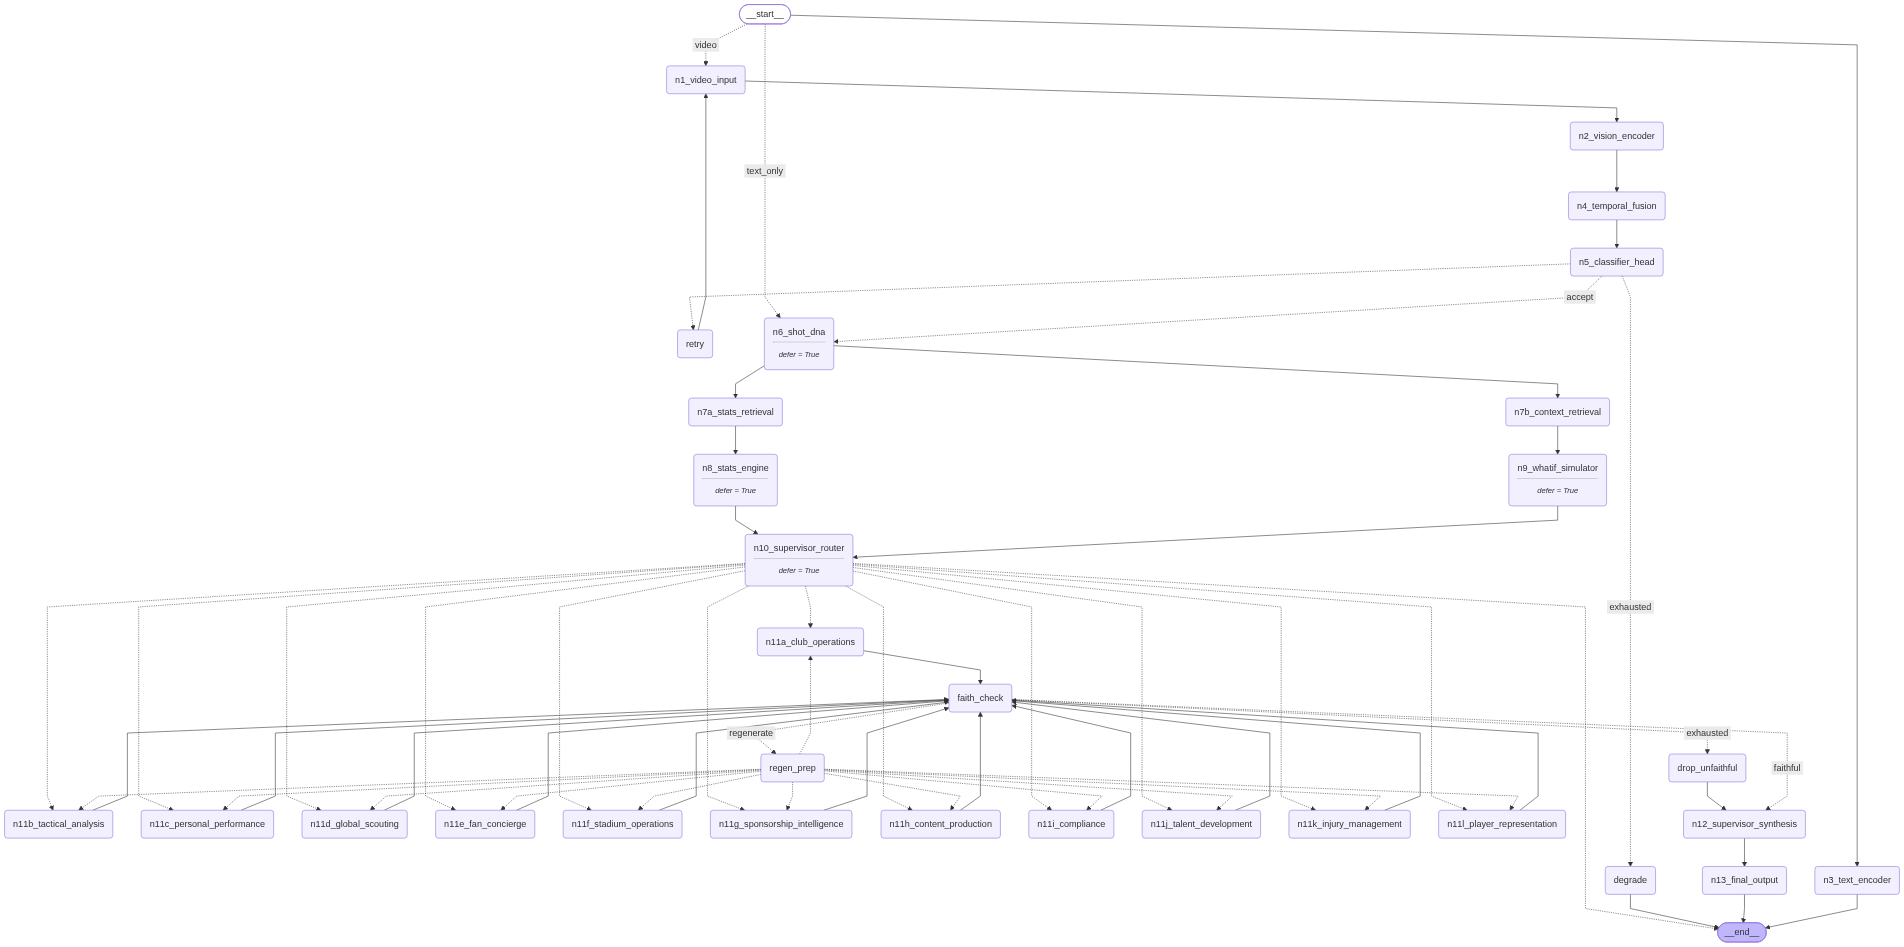

In [92]:
cricketmind = build_cricketmind_graph()
show_graph(cricketmind)

In [93]:
#9A: nothing fabricated -> straight through
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = set(), set()
STUB_CONFIDENCE = 0.92
r9a = cricketmind.invoke(new_state("clips/kohli_01.mp4", QUERY))
print()
assert r9a["faith_failures"] == []
assert r9a.get("regen_count", 0) == 0
assert r9a["status"] == "ok"
print("OK: verified findings pass the gate untouched")

  [START] video query
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007
  [N10  ] woke 2/12: Players, Coaches
  [  -> ] n11c_personal_performance: query mentions shot, drive, pull
  [  -> ] n11b_tactical_analysis: query mentions bowl; SR spread 30 between shots
  [N11  ] Coaches: cites ['best_sr', 'worst_sr', 'p_pc

In [94]:
# 9B: one agent fabricates, is caught, and is regenerated
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = {"n11b_tactical_analysis"}, set()
r9b = cricketmind.invoke(new_state("clips/kohli_01.mp4", QUERY))
HALLUCINATE_ONCE = set()

print()
print("regen_count      :", r9b["regen_count"])
print("failures at end  :", r9b["faith_failures"])
for f in r9b["agent_findings"]:
    print(f"  {f['agent']:32s} {f['cites']}")

assert r9b["regen_count"] == 1,        "the loop did not fire exactly once"
assert r9b["faith_failures"] == [],    "the corrected finding still fails"
assert not any(999.0 in f["cites"].values() for f in r9b["agent_findings"])
assert len(r9b["agent_findings"]) == len(r9b["active_agents"]), "upsert duplicated"
print()
print("OK: fabrication caught, agent re-run, corrected value replaced the bad one")

  [START] video query
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007
  [N10  ] woke 2/12: Players, Coaches
  [  -> ] n11c_personal_performance: query mentions shot, drive, pull
  [  -> ] n11b_tactical_analysis: query mentions bowl; SR spread 30 between shots
  [N11  ] Coaches: cites ['best_sr', 'worst_sr', 'p_pc

In [95]:
# 9C: an agent that never corrects -> claims withheld
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = set(), {"n11b_tactical_analysis"}
r9c = cricketmind.invoke(new_state("clips/kohli_01.mp4", QUERY))
HALLUCINATE_ALWAYS = set()

print()
print("regen_count :", r9c["regen_count"], "| status:", r9c["status"])
for f in r9c["agent_findings"]:
    print(f"  {f['agent']:32s} rejected={f.get('rejected', False)}")

assert r9c["regen_count"] == MAX_REGENS
assert r9c["status"] == "unverified_claims_dropped"
assert any(f.get("rejected") for f in r9c["agent_findings"])
print()
print("OK: budget spent, unverifiable claim withheld rather than published")

  [START] video query
  [N1   ] sampled 15 frames from clips/kohli_01.mp4
  [N3   ] query -> (768,), filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N2   ] encoded 15 frames -> (15, 1280)
  [N4   ] (15, 1280) -> self-attention (2L/4H) -> (1280,)
  [N5   ] attempt 0: Cover Drive (idx 0) p=0.92
  [GATE ] p=0.92 >= 0.7 -> accept
  [N6   ] shot_dna: Cover Drive p=0.92 filters={'bowler_type': 'pace', 'phase': 'powerplay', 'player': 'Kohli', 'shots': ['Cover Drive', 'Pull']}
  [N7a  ] shots=['Cover Drive', 'Pull'] -> 100 deliveries (from 150)
  [N7b  ] player=Kohli -> 4 context rows
  [N8   ] Cover Drive: SR 142.0  Pull: SR 112.0
  [N9   ] Pull: p_ball=0.080 -> P(out in 6) = 0.394 +/- 0.007
  [N10  ] woke 2/12: Players, Coaches
  [  -> ] n11c_personal_performance: query mentions shot, drive, pull
  [  -> ] n11b_tactical_analysis: query mentions bowl; SR spread 30 between shots
  [N11  ] Coaches: cites ['best_sr', 'worst_sr', 'p_pc

In [96]:
# 10: the whole system, end to end 
TRACE = False
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = set(), set()
STUB_CONFIDENCE = 0.92
final = cricketmind.invoke(new_state("clips/kohli_01.mp4", QUERY))
TRACE = True

print(final["report"])

CRICKETMIND REPORT -- Kohli
Query      : Compare Kohli's cover drive vs his pull shot against fast bowlers in the powerplay
Vision     : Cover Drive at 92% confidence (1 attempt(s))
Evidence   : 100 deliveries -- Cover Drive SR 142.0, Pull SR 112.0
Simulation : 6 consecutive deliveries targeting the pull -> 39.4% (95% CI 38.7%-40.1%, 20,000 trials)

FINDINGS (2 agent(s))
------------------------------------------------------------------------
[Players]
  Weight transfer on the Cover Drive measures 0.88, and it is the stronger stroke at SR 142.0. The Pull lags at SR 112.0 -- shot selection, not technique, is the gap to close.

[Coaches]
  Bowl short at Kohli. The Pull returns SR 112.0 against the Cover Drive's SR 142.0; 6 consecutive back-of-a-length deliveries carry a 39.4% chance of dismissal.



In [97]:
# 10B: coverage against Architecture v2
nodes = [n for n in cricketmind.get_graph().nodes if not n.startswith("__")]
expected = {
    "N1-N5 perception":   ["n1_video_input", "n2_vision_encoder", "n4_temporal_fusion",
                           "n5_classifier_head", "n3_text_encoder"],
    "gates + loops":      ["retry", "degrade", "faith_check", "regen_prep", "drop_unfaithful"],
    "N6 grounding":       ["n6_shot_dna"],
    "N7 retrieval":       ["n7a_stats_retrieval", "n7b_context_retrieval"],
    "N8/N9 services":     ["n8_stats_engine", "n9_whatif_simulator"],
    "N10 router":         ["n10_supervisor_router"],
    "N11a-l agents":      list(AGENT_NODES),
    "N12/N13 synthesis":  ["n12_supervisor_synthesis", "n13_final_output"],
}
for group, names in expected.items():
    missing = [n for n in names if n not in nodes]
    print(f"  {group:20s} {len(names):2d} node(s)  {'OK' if not missing else 'MISSING ' + str(missing)}")
    assert not missing

print(f"\n  total: {len(nodes)} nodes, {len(AGENT_NODES)} of them stakeholder agents")
print("  14 agents = 12 stakeholder-facing + 2 shared analytical services (N8, N9)")

  N1-N5 perception      5 node(s)  OK
  gates + loops         5 node(s)  OK
  N6 grounding          1 node(s)  OK
  N7 retrieval          2 node(s)  OK
  N8/N9 services        2 node(s)  OK
  N10 router            1 node(s)  OK
  N11a-l agents        12 node(s)  OK
  N12/N13 synthesis     2 node(s)  OK

  total: 30 nodes, 12 of them stakeholder agents
  14 agents = 12 stakeholder-facing + 2 shared analytical services (N8, N9)


In [98]:
# 10C: Mermaid source, for pasting into the thesis
print(cricketmind.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	n1_video_input(n1_video_input)
	n2_vision_encoder(n2_vision_encoder)
	n4_temporal_fusion(n4_temporal_fusion)
	n5_classifier_head(n5_classifier_head)
	n3_text_encoder(n3_text_encoder)
	retry(retry)
	degrade(degrade)
	n6_shot_dna(n6_shot_dna<hr/><small><em>defer = True</em></small>)
	n7a_stats_retrieval(n7a_stats_retrieval)
	n7b_context_retrieval(n7b_context_retrieval)
	n8_stats_engine(n8_stats_engine<hr/><small><em>defer = True</em></small>)
	n9_whatif_simulator(n9_whatif_simulator<hr/><small><em>defer = True</em></small>)
	n10_supervisor_router(n10_supervisor_router<hr/><small><em>defer = True</em></small>)
	n11a_club_operations(n11a_club_operations)
	n11b_tactical_analysis(n11b_tactical_analysis)
	n11c_personal_performance(n11c_personal_performance)
	n11d_global_scouting(n11d_global_scouting)
	n11e_fan_concierge(n11e_fan_concierge)
	n11f_stadium_operations(n11f_stadium_operations)
	n11g_sp

In [99]:
cricketmind.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'n1_video_input': Node(id='n1_video_input', name='n1_video_input', data=n1_video_input(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'n2_vision_encoder': Node(id='n2_vision_encoder', name='n2_vision_encoder', data=n2_vision_encoder(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'n4_temporal_fusion': Node(id='n4_temporal_fusion', name='n4_temporal_fusion', data=n4_temporal_fusion(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'n5_classifier_head': Node(id='n5_classifier_head', name='n5_classifier_head', data=n5_classifier_head(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'n3_text_encoder': Node(id='n3_text_encoder', name='n3_text_encoder', data=n3_text_encoder(tags=None, recurse=True, explode_ar

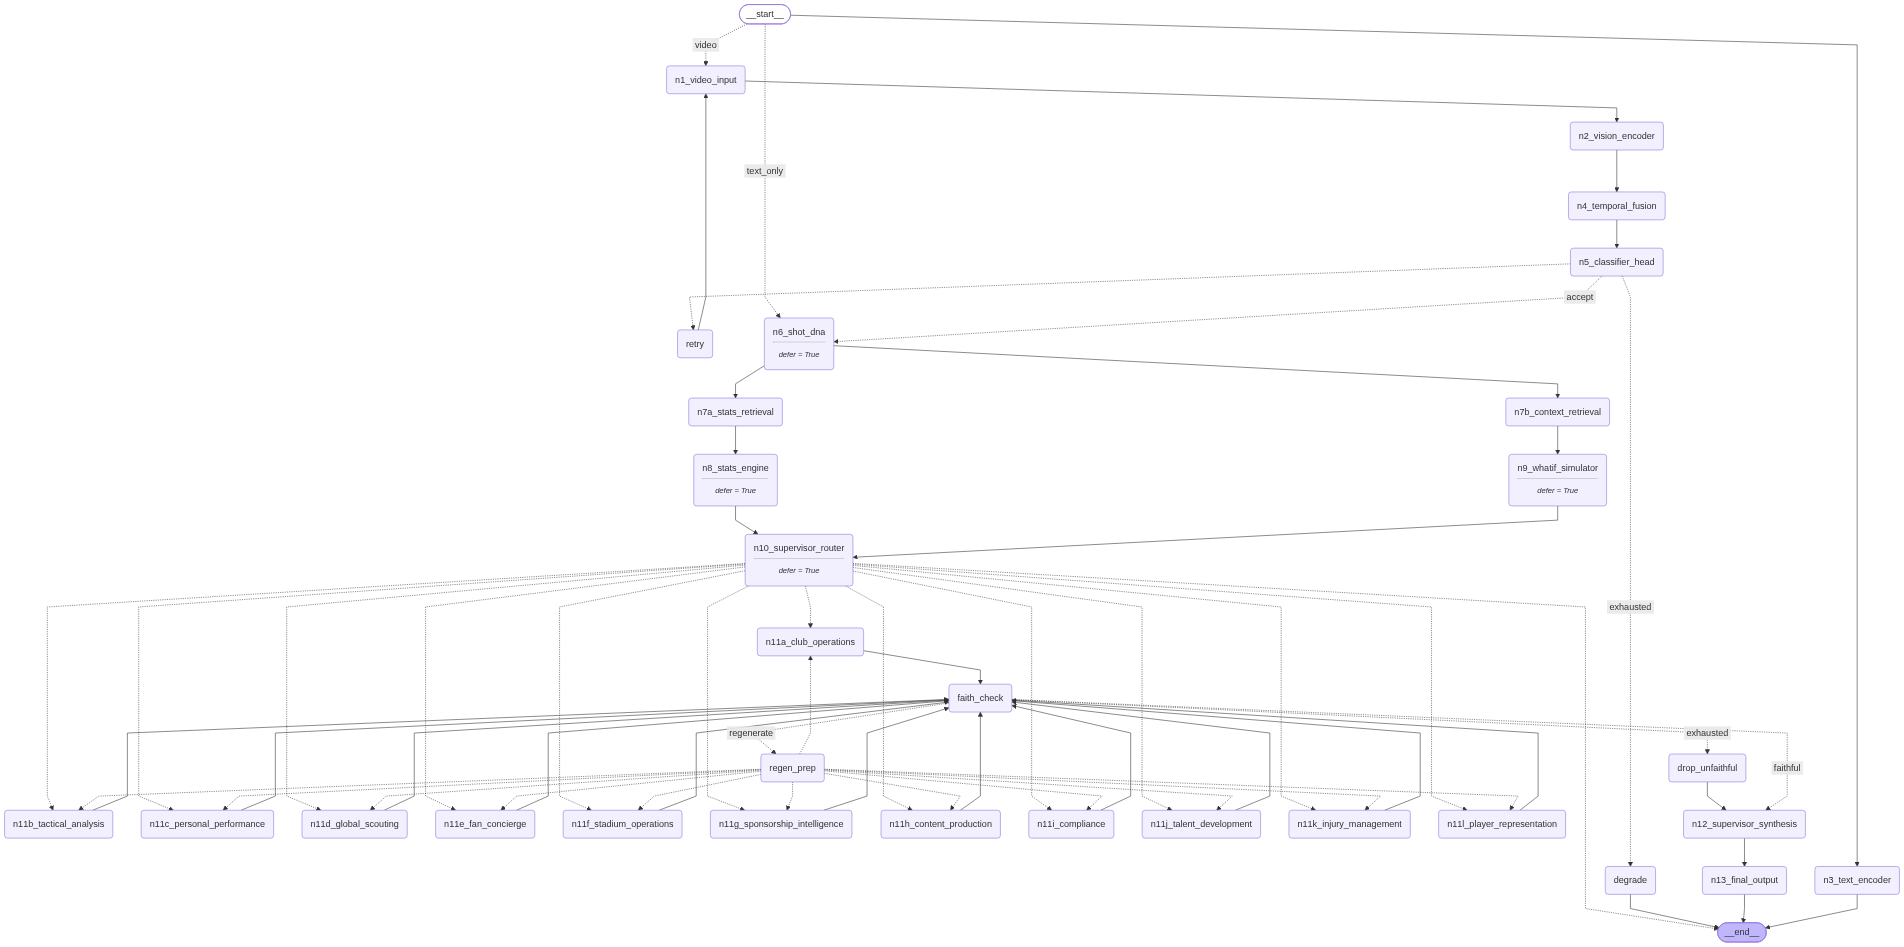

In [100]:
show_graph(cricketmind)

### Checkpoint: both entry paths

Five checks. The first confirms nothing about the video path changed; the rest
exercise the new one. The last is the check that caught a real bug once already
--- a wrong `defer` setting produces a correct run and a wrong diagram.

In [101]:
# 13A: the video path behaves exactly as before
TRACE = False
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = set(), set()
STUB_CONFIDENCE = 0.92
rv = cricketmind.invoke(new_state("clips/kohli_01.mp4", QUERY))
TRACE = True

assert rv["shot_dna"]["modality"] == "video"
assert rv["shot_dna"]["shot"]     is not None
assert rv["shot_dna"]["posture"]  is not None
assert rv["status"] == "ok"
assert rv["faith_failures"] == []
print("OK: video path unchanged --", rv["shot_dna"]["shot"],
      "| agents:", len(rv["active_agents"]))

OK: video path unchanged -- Cover Drive | agents: 2


In [102]:
# 13B: a text-only query never enters the vision branch
TRACE = False
rt = cricketmind.invoke(new_state(None, QUERY))
TRACE = True

assert rt["shot_dna"]["modality"] == "text"
assert rt["shot_dna"]["shot"]     is None
assert rt["shot_dna"]["posture"]  is None
assert "frames"     not in rt,  "N1 ran on a query with no clip"
assert "shot_label" not in rt,  "the classifier ran on a query with no clip"
assert rt["retry_count"] == 0
assert rt["stats_hits"],        "retrieval found nothing from the query's own shots"
assert rt["status"] == "ok"
print("OK: text-only path reached the report without the vision branch")
print("    deliveries retrieved:", len(rt["stats_hits"]))

OK: text-only path reached the report without the vision branch
    deliveries retrieved: 100


In [103]:
# 13C: agents whose evidence does not exist are not woken
posture_agents = {a["id"] for a in AGENT_REGISTRY if "weight_transfer" in a["cites"]}
woke = set(rt["active_agents"])
assert not (woke & posture_agents), f"woke an agent with no posture evidence: {woke & posture_agents}"

facts_t = sanctioned_facts(rt)
assert "weight_transfer" not in facts_t, "posture leaked into the sanctioned facts"
assert "shot"            not in facts_t
assert "weight_transfer" in sanctioned_facts(rv), "video path lost its posture facts"

print("OK: text-only facts =", sorted(facts_t))
print("    blocked agents  =", sorted(AGENTS_BY_ID[a]["stakeholder"] for a in posture_agents))
print("    woke            =", [AGENTS_BY_ID[a]["stakeholder"] for a in woke])

OK: text-only facts = ['best_shot', 'best_sr', 'career_sr', 'deliveries', 'p_pct', 'player', 'sample_size', 'target_shot', 'venue_sr', 'worst_shot', 'worst_sr']
    blocked agents  = ['Academies', 'Players']
    woke            = ['Coaches']


In [104]:
# 13D: verification still works on the text-only path
TRACE = False
HALLUCINATE_ALWAYS = set()
HALLUCINATE_ONCE   = {rt["active_agents"][0]}
rt2 = cricketmind.invoke(new_state(None, QUERY))
HALLUCINATE_ONCE   = set()
TRACE = True

assert rt2["regen_count"] == 1, "the fabrication was not caught on the text path"
assert rt2["faith_failures"] == []
assert not any(999.0 in f["cites"].values() for f in rt2["agent_findings"])
print("OK: fabrication caught and regenerated on a text-only query too")

OK: fabrication caught and regenerated on a text-only query too


In [105]:
# 13E: the rendered graph shows both entry paths and no phantom edges
edges = [(e.source, e.target) for e in cricketmind.get_graph().edges]
srcs  = {t for s, t in edges if s == "__start__"}
assert "n1_video_input"  in srcs, "video entry missing"
assert "n6_shot_dna"     in srcs, "text-only entry missing"
assert "n3_text_encoder" in srcs, "the text encoder no longer runs on both paths"
assert ("n13_final_output", "__end__") in edges, "lost n13 -> END"
print("OK: START ->", sorted(srcs))
print("   ", len(edges), "edges total")

OK: START -> ['n1_video_input', 'n3_text_encoder', 'n6_shot_dna']
    61 edges total


In [106]:
# 13F: the same query, answered without a clip
print(rt["report"])

CRICKETMIND REPORT -- Kohli
Query      : Compare Kohli's cover drive vs his pull shot against fast bowlers in the powerplay
Vision     : no clip supplied -- text-only query
Evidence   : 100 deliveries -- Cover Drive SR 142.0, Pull SR 112.0
Simulation : 6 consecutive deliveries targeting the pull -> 39.4% (95% CI 38.7%-40.1%, 20,000 trials)

FINDINGS (1 agent(s))
------------------------------------------------------------------------
[Coaches]
  Bowl short at Kohli. The Pull returns SR 112.0 against the Cover Drive's SR 142.0; 6 consecutive back-of-a-length deliveries carry a 39.4% chance of dismissal.

